# 1. Wilson–Cowan Network Model (3 Nodes)
## Dynamical Regimes, Oscillations, and Criticality-Oriented Metrics

This notebook implements a Wilson–Cowan network composed of three coupled areas.
The system is numerically integrated using a fourth-order Runge–Kutta scheme.

The objective is to explore the dynamical regimes of the model, identify the onset of oscillations,
and prepare the simulated signals for higher-order criticality metrics.


## 2. Wilson–Cowan Model

Each node consists of an excitatory (E) and inhibitory (I) population.
The dynamics of the network are described by the Wilson–Cowan equations in vector form:

$$
\tau \frac{dU}{dt} = -U +  \, S(CU + B)
$$

where:

- $U = [E_1, I_1, E_2, I_2, E_3, I_3]$ is the state vector
- $S(\cdot)$ is a sigmoid activation function
- $C$ encodes local and inter-node coupling
- $B$ represents external inputs and bias terms
- $\tau = diag(τ_e, τ_i)$ represents time constants 

For 3x3 connectivity we have  $u = (E, I, J)^T$ , $T= diag(τ_e, τ_i, τ_j)$, $C = (C_{ij})$, and $B = (P, Q, R)^T$ . Here, $v^T$ represents the transpose of vector v. In fact, τ, C, and B can be time-dependent.

### Fixed Model Parameters

Unless explicitly stated otherwise, the following parameters are kept fixed
and are taken from:

**Liu et al. (2024)**  
*Criticality and Partial Synchronization Analysis in Wilson–Cowan and Jansen–Rit Neural Mass Models.*

#### Local population dynamics (Table 1 in Liu et al., 2024)

- Excitatory time constant:
$$
\tau_E = 0.12
$$

- Inhibitory time constant:
$$
\tau_I = 0.25
$$

- Sigmoid gain parameters:
$$
a_E = 0.8, \quad a_I = 0.8
$$

- Sigmoid thresholds:
$$
\theta_E = 2.0, \quad \theta_I = 8.0
$$

- Local coupling strengths:
$$
c_{EE} = 8.0, \quad c_{EI} = 16.0, \quad c_{IE} = 8.0, \quad c_{II} = 0.4
$$

#### External inputs (baseline values)

- Excitatory baseline input:
$$
P_{\text{baseline}} = 1.5
$$

- Inhibitory baseline input:
$$
Q_{\text{baseline}} = -2.0
$$

#### Noise and numerical parameters

- Noise standard deviation:
$$
\sigma_{\text{noise}} = 0.01
$$

- Integration time step:
$$
h = 10^{-3}
$$

- Total simulation time:
$$
T = 10.0
$$

- Sampling interval:
$$
\Delta t_{\text{save}} = 10^{-3}
$$

Initial conditions are set using small-amplitude random perturbations
around zero for both excitatory and inhibitory populations.

All other parameters not listed here are explicitly explored or modified
as part of the model analysis.


## 3. Imports and Global Configuration

This section imports all required Python libraries and defines global
configuration parameters used throughout the notebook.


In [5]:
# -------------------------------------------------------------
# Imports and global configuration
# -------------------------------------------------------------

import numpy as np
import sys
np.set_printoptions(threshold=sys.maxsize)

import matplotlib.pyplot as plt

# Reproducibility
seed = 42
np.random.seed(seed)

# Matplotlib default settings
plt.rcParams.update({
    "figure.figsize": (8, 4),
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False
})





# -------------------------------------------------------------
# Fixed Wilson–Cowan parameters (Liu et al., 2024)
# -------------------------------------------------------------

# Number of nodes (will be reduced to 3 later)
N = 3

# Time constants
tauE = 0.12
tauI = 0.25

# Sigmoid parameters (fixed, not to be modified)
aE = 0.8
aI = 0.8
thetaE = 2.0
thetaI = 8.0

# Local connectivity coefficients
cEE = 8.0
cEI = 16.0
cIE = 8.0
cII = 0.4

# Baseline external inputs (P will be varied later)
P_baseline = 1.5
Q_baseline = -2.0

# Noise strength
sigma_noise = 0.01

# Numerical integration parameters
dt = 1e-3
T = 10.0
save_dt = 1e-3

## 4. Activation Function

The Wilson–Cowan model uses a sigmoidal activation function to map synaptic input
into population firing rates. In this study, the activation function is fixed and
kept identical across all simulations in order to start from a minimal and
well-controlled model configuration.

The activation function is defined as:

$$
S(x) = \frac{1}{1 + e^{-a x}}
$$

where $a$ controls the slope of the sigmoid. This function is applied elementwise
to all state variables.


In [6]:
# -------------------------------------------------------------
# Sigmoid activation function (fixed, do not modify)
# -------------------------------------------------------------

def S(x, a=0.8, theta=2.0):
    """
    Sigmoid activation function applied elementwise.

    Parameters
    ----------
    x : array_like
        Synaptic input.
    a : float
        Slope of the sigmoid (fixed).
    theta : float
        Threshold parameter (kept for compatibility, not used).

    Returns
    -------
    array_like
        Output firing rate.
    """
    return 1.0 / (1.0 + np.exp(-a * x))


## 5. Network Connectivity

Inter-node coupling is defined by the following adjacency matrix:

$$
M =
\begin{pmatrix}
0 & 1 & 1 \\
1 & 0 & 1 \\
1 & 1 & 0
\end{pmatrix}
$$

where $M_{ij} = 1$ indicates a directed connection from node $j$ to node $i$.
The overall coupling strength is controlled by a scalar parameter $K$


In [7]:
# -------------------------------------------------------------
# Network connectivity (3-node system)
# -------------------------------------------------------------

# Adjacency matrix (directed connectivity)
M = np.array([
    [0.0, 1.0, 1.0],
    [1.0, 0.0, 1.0],
    [1.0, 1.0, 0.0]
])

# Global coupling strength (to be varied later)
K_global = 0.0  # placeholder value


## 6. Wilson–Cowan Vector Field

This section defines the vector field of the Wilson–Cowan model for a network of
three coupled nodes. Each node consists of an excitatory population $E_i(t)$ and
an inhibitory population $I_i(t)$.

The dynamical equations for node $i$ are given by:

$$
\tau_E \frac{dE_i}{dt}
= -E_i
+ S\left(
c_{EE} E_i
- c_{EI} I_i
+ P
+ K \sum_{j} M_{ij} E_j
\right)
$$

$$
\tau_I \frac{dI_i}{dt}
= -I_i
+ S\left(
c_{IE} E_i
- c_{II} I_i
+ Q
\right)
$$

where $M$ is the adjacency matrix defining the network topology and $K$ controls
the global coupling strength. The function $S(\\cdot)$ is the fixed sigmoid
activation defined in the previous section.


In [54]:
# -------------------------------------------------------------
# Wilson–Cowan vector field for a 3-node network
# -------------------------------------------------------------

def wc_rhs(state, P, K, M):
    """
    Right-hand side of the Wilson–Cowan equations for a network.

    Parameters
    ----------
    state : ndarray, shape (2*N,)
        Current state vector [E_1,...,E_N, I_1,...,I_N].
    P : float
        External excitatory input.
    K : float
        Global coupling strength.
    M : ndarray, shape (N, N)
        Adjacency matrix.

    Returns
    -------
    dstate_dt : ndarray, shape (2*N,)
        Time derivative of the state.
    """
    N = M.shape[0]

    # Split state vector
    E = state[:N]
    I = state[N:]

    # Coupling term (excitatory-to-excitatory)
    coupling = K * M @ E

    # Excitatory population dynamics
    dE_dt = (
        -E
        + S(cEE * E - cEI * I + P + coupling)
    ) / tauE

    # Inhibitory population dynamics
    dI_dt = (
        -I
        + S(cIE * E - cII * I + Q_baseline)
    ) / tauI

    # Concatenate derivatives
    dstate_dt = np.concatenate([dE_dt, dI_dt])

    return dstate_dt


## 7. Numerical Integration (Runge–Kutta 4)

The Wilson–Cowan system is numerically integrated using a fourth-order
Runge–Kutta (RK4) scheme. This method provides a good balance between numerical
accuracy and computational efficiency for nonlinear dynamical systems.

Given a dynamical system

$$
\frac{d\mathbf{x}}{dt} = f(\mathbf{x}),
$$

the RK4 update rule with time step $\Delta t$ is:

$$
\mathbf{x}_{t+1} = \mathbf{x}_t
+ \frac{\Delta t}{6}(k_1 + 2k_2 + 2k_3 + k_4),
$$

where

$$
\begin{aligned}
k_1 &= f(\mathbf{x}_t), \\\\
k_2 &= f\left(\mathbf{x}_t + \frac{\Delta t}{2}k_1\right), \\\\
k_3 &= f\left(\mathbf{x}_t + \frac{\Delta t}{2}k_2\right), \\\\
k_4 &= f(\mathbf{x}_t + \Delta t\, k_3).
\end{aligned}
$$


In [9]:
# -------------------------------------------------------------
# Runge–Kutta 4 integrator
# -------------------------------------------------------------

def rk4_step(f, state, dt, *args):
    """
    Perform a single RK4 integration step.

    Parameters
    ----------
    f : callable
        Vector field function.
    state : ndarray
        Current state vector.
    dt : float
        Time step.
    *args :
        Additional arguments passed to the vector field.

    Returns
    -------
    state_next : ndarray
        Updated state vector after one RK4 step.
    """
    k1 = f(state, *args)
    k2 = f(state + 0.5 * dt * k1, *args)
    k3 = f(state + 0.5 * dt * k2, *args)
    k4 = f(state + dt * k3, *args)

    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def simulate_wc(state0, P, K, M, T, dt):
    """
    Simulate the Wilson–Cowan network dynamics over time.

    Parameters
    ----------
    state0 : ndarray
        Initial state vector.
    P : float
        External excitatory input.
    K : float
        Global coupling strength.
    M : ndarray
        Adjacency matrix.
    T : float
        Total simulation time.
    dt : float
        Time step.

    Returns
    -------
    t : ndarray
        Time vector.
    states : ndarray
        Time series of state vectors.
    """
    n_steps = int(T / dt)
    t = np.linspace(0, T, n_steps)

    states = np.zeros((n_steps, len(state0)))
    states[0] = state0.copy()

    for i in range(1, n_steps):
        states[i] = rk4_step(wc_rhs, states[i-1], dt, P, K, M)

    return t, states


## 8. Single Simulation Example

This section presents a single simulation of the three-node Wilson–Cowan network
for a fixed choice of the control parameters $P$ and $K$. The goal is to visualize
the temporal evolution of the excitatory populations and verify that the numerical
integration behaves as expected.

The state vector is initialized with small random perturbations around zero in
order to avoid trivial fixed points.


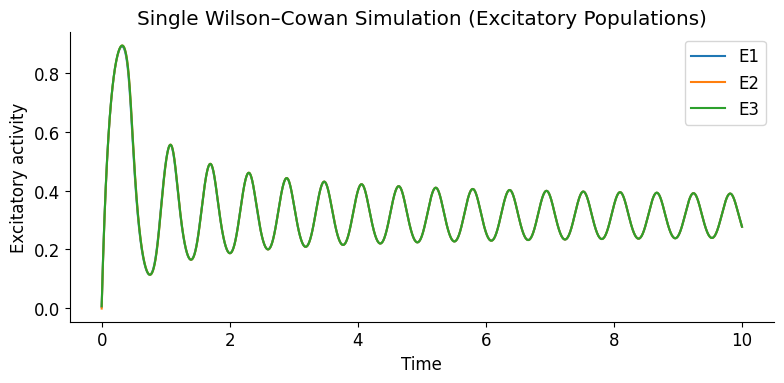

In [10]:
# -------------------------------------------------------------
# Single simulation example
# -------------------------------------------------------------

# Initial conditions (small random perturbations)
state0 = 0.01 * np.random.randn(2 * N)

# Control parameters (example values)
P_example = 5.0
K_example = 0.5

# Run simulation
t, states = simulate_wc(
    state0=state0,
    P=P_example,
    K=K_example,
    M=M,
    T=T,
    dt=dt
)

# Extract excitatory populations
E = states[:, :N]

# Plot excitatory activity
plt.figure()
for i in range(N):
    plt.plot(t, E[:, i], label=f"E{i+1}")

plt.xlabel("Time")
plt.ylabel("Excitatory activity")
plt.title("Single Wilson–Cowan Simulation (Excitatory Populations)")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Phase Space Analysis

Phase space analysis provides insight into the qualitative behavior of the
Wilson–Cowan dynamics beyond time-domain observations. By plotting the excitatory
activity $E_i(t)$ against the inhibitory activity $I_i(t)$ for a given node, it is
possible to identify fixed points, transient trajectories, and oscillatory
regimes such as limit cycles.

In this section, the phase portrait is shown for a single node after discarding
an initial transient period.


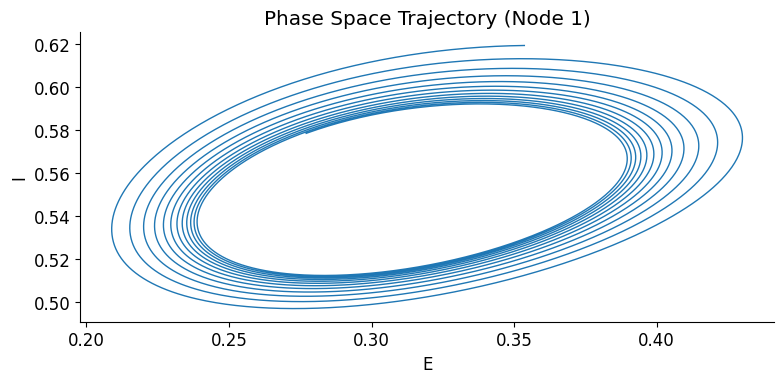

In [11]:
# -------------------------------------------------------------
# Phase space analysis (E vs I)
# -------------------------------------------------------------

# Extract inhibitory populations
I = states[:, N:]

# Discard initial transient
transient_fraction = 0.3
start_idx = int(transient_fraction * len(t))

# Select one node (node 1)
E_node = E[start_idx:, 0]
I_node = I[start_idx:, 0]

# Phase space plot
plt.figure()
plt.plot(E_node, I_node, lw=1)
plt.xlabel("E")
plt.ylabel("I")
plt.title("Phase Space Trajectory (Node 1)")
plt.tight_layout()
plt.show()


## 10. Oscillation Detection

To systematically identify oscillatory regimes in the Wilson–Cowan network,
a quantitative criterion is required. Visual inspection of time series or
phase portraits is insufficient when performing large parameter sweeps.

In this study, oscillations are detected by measuring the temporal variance of
the excitatory activity after discarding an initial transient. A nonzero variance
above a small threshold indicates sustained oscillatory dynamics, whereas
near-zero variance corresponds to convergence to a fixed point.


Total timesteps: 10000
Using start_idx: 5000
E_node length: 5000
E range: [0.2270, 0.4096]
I range: [0.5047, 0.6027]
E variance: 0.003342

Limit cycle detected: True
Crossings found: 9
Dispersion: 0.023851
Period: 0.5750


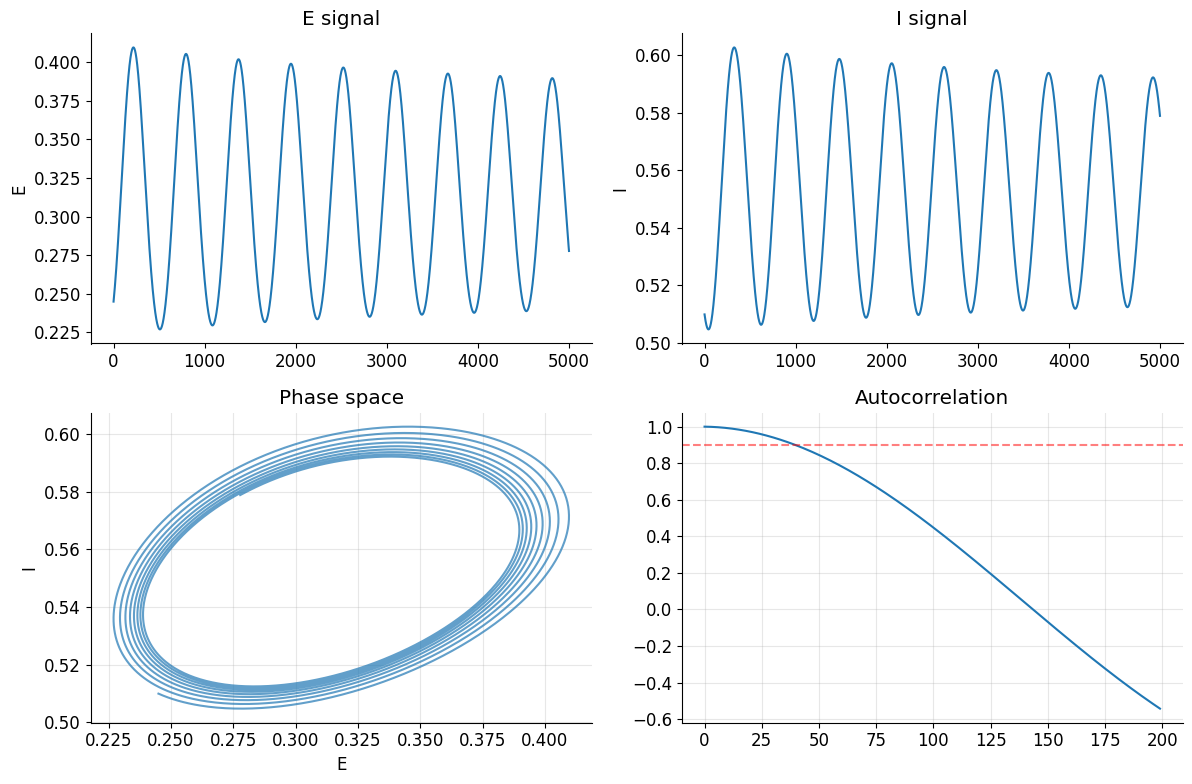

In [12]:
# -------------------------------------------------------------
# Limit Cycle detection via Poincaré Section
# -------------------------------------------------------------

def detect_limit_cycle_poincare(E_signal, I_signal, dt, 
                                threshold_ratio=0.05,
                                period_cv_threshold=0.10):
    """Detect limit cycle using Poincaré section method."""

    """
    Detect limit cycle using Poincaré section method.
    
    Parameters
    ----------
    E_signal : ndarray
        Excitatory population activity time series (after transient).
    I_signal : ndarray
        Inhibitory population activity time series (after transient).
    dt : float
        Time step of the simulation.
    threshold_ratio : float
        Maximum dispersion ratio for Poincaré points (default: 0.02 = 2%).
    period_cv_threshold : float
        Maximum period variation allowed (default: 0.05 = 5%).
    
    Returns
    -------
    is_limit_cycle : bool
        True if limit cycle dynamics are detected.
    period : float or None
        Estimated period of oscillation in time units.
    dispersion : float
        Normalized dispersion of Poincaré points.
    """
    
    E_mean = np.mean(E_signal)
    E_centered = E_signal - E_mean
    
    crossings = []
    for i in range(len(E_centered) - 1):
        if E_centered[i] <= 0 < E_centered[i+1]:
            alpha = -E_centered[i] / (E_centered[i+1] - E_centered[i])
            I_cross = I_signal[i] + alpha * (I_signal[i+1] - I_signal[i])
            t_cross = (i + alpha) * dt
            crossings.append((t_cross, I_cross))
    
    if len(crossings) < 3:
        return False, None, np.inf, len(crossings)
    
    times = np.array([c[0] for c in crossings])
    I_values = np.array([c[1] for c in crossings])
    
    I_range = np.max(I_signal) - np.min(I_signal)
    if I_range == 0:
        return False, None, np.inf, len(crossings)
    
    dispersion = np.std(I_values) / I_range
    periods = np.diff(times)
    period_mean = np.mean(periods)
    period_cv = np.std(periods) / period_mean if period_mean > 0 else np.inf
    
    is_limit_cycle = (dispersion < threshold_ratio and period_cv < period_cv_threshold)
    
    return is_limit_cycle, period_mean, dispersion, len(crossings)



# -------------------------------------------------------------
# Example: detect limit cycle in node 0
# -------------------------------------------------------------

P_test = 5.0
K_test = 0.5

state0 = 0.01 * np.random.randn(2 * N)

t, states = simulate_wc(
    state0=state0,
    P=P_test,
    K=K_test,
    M=M,
    T=T,
    dt=dt
)

print(f"Total timesteps: {len(states)}")

# CORREGIR: start_idx debe ser menor que len(states)
start_idx_corrected = len(states) // 2  # Descarta primera mitad

print(f"Using start_idx: {start_idx_corrected}")

# Extraer E e I después del transiente
E = states[start_idx_corrected:, :N]
I = states[start_idx_corrected:, N:]

E_node = E[:, 0]
I_node = I[:, 0]

print(f"E_node length: {len(E_node)}")
print(f"E range: [{E_node.min():.4f}, {E_node.max():.4f}]")
print(f"I range: [{I_node.min():.4f}, {I_node.max():.4f}]")
print(f"E variance: {np.var(E_node):.6f}")

is_lc, period, dispersion, n_crossings = detect_limit_cycle_poincare(E_node, I_node, dt)

print(f"\nLimit cycle detected: {is_lc}")
print(f"Crossings found: {n_crossings}")
print(f"Dispersion: {dispersion:.6f}")
if period:
    print(f"Period: {period:.4f}")

# Visualización
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(E_node)
axes[0, 0].set_title("E signal")
axes[0, 0].set_ylabel("E")

axes[0, 1].plot(I_node)
axes[0, 1].set_title("I signal")
axes[0, 1].set_ylabel("I")

axes[1, 0].plot(E_node, I_node, alpha=0.7)
axes[1, 0].set_xlabel("E")
axes[1, 0].set_ylabel("I")
axes[1, 0].set_title("Phase space")
axes[1, 0].grid(True, alpha=0.3)

E_centered = E_node - np.mean(E_node)
autocorr = np.correlate(E_centered, E_centered, mode='full')
autocorr = autocorr[len(autocorr)//2:] / autocorr[len(autocorr)//2]

axes[1, 1].plot(autocorr[:min(200, len(autocorr))])
axes[1, 1].set_title("Autocorrelation")
axes[1, 1].axhline(y=0.9, color='r', linestyle='--', alpha=0.5)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Parameter Sweep (P × K)

To identify the regions of parameter space where oscillations emerge, a systematic
parameter sweep is performed over the external excitatory input $P$ and the global
coupling strength $K$.

The explored ranges are:
- $P \in [1, 10]$
- $K \in [0, 1]$

For each $(P, K)$ pair, the Wilson–Cowan network is simulated and oscillatory
behavior is detected using the variance-based criterion defined previously.
The result is a binary map indicating the presence or absence of oscillations
across the parameter space.


In [13]:
# -------------------------------------------------------------
# Parameter sweep over P and K
# -------------------------------------------------------------

P_values = np.linspace(1.0, 10.0, 20)
K_values = np.linspace(0.0, 1.0, 20)

oscillation_map = np.zeros((len(P_values), len(K_values)), dtype=int)

state0 = 0.01 * np.random.randn(2 * N)

for i, P_val in enumerate(P_values):
    for j, K_val in enumerate(K_values):

        t, states = simulate_wc(
            state0=state0,
            P=P_val,
            K=K_val,
            M=M,
            T=T,
            dt=dt
        )

        # using alf index
        start_idx_sweep = len(states) // 2
        
        E = states[start_idx_sweep:, :N]
        I = states[start_idx_sweep:, N:]
        
        E_node = E[:, 0]
        I_node = I[:, 0]

        is_lc, period, dispersion, n_crossings = detect_limit_cycle_poincare(E_node, I_node, dt)
        oscillation_map[i, j] = int(is_lc)
    
    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


## 12. P–K Oscillation Map

This section visualizes the results of the parameter sweep as a two-dimensional
map in the $(P, K)$ parameter space. Each point indicates whether the
Wilson–Cowan network exhibits sustained oscillations.

The map highlights the boundary between fixed-point dynamics and oscillatory
regimes, which is associated with the onset of collective rhythmic activity.


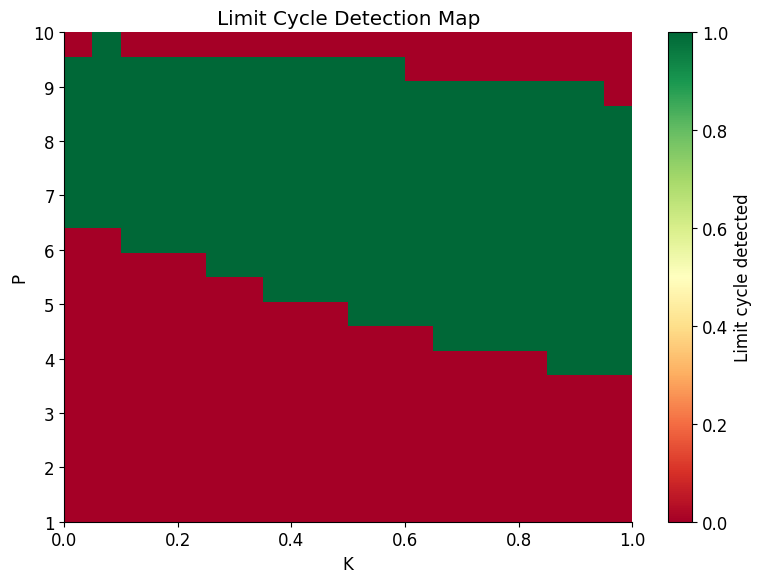


Total limit cycles detected: 198/400
Percentage: 49.5%


In [14]:
# -------------------------------------------------------------
# Visualization of the P–K oscillation map
# -------------------------------------------------------------

plt.figure(figsize=(8, 6))
plt.imshow(oscillation_map, origin="lower", aspect="auto",
           extent=[K_values[0], K_values[-1], P_values[0], P_values[-1]],
           cmap='RdYlGn')
plt.colorbar(label="Limit cycle detected")
plt.xlabel("K")
plt.ylabel("P")
plt.title("Limit Cycle Detection Map")
plt.tight_layout()
plt.show()

print(f"\nTotal limit cycles detected: {np.sum(oscillation_map)}/{oscillation_map.size}")
print(f"Percentage: {100 * np.mean(oscillation_map):.1f}%")


## 13. Signal Preparation for Higher-Order Metrics

Higher-order interaction metrics require multivariate time series as input.
In this section, excitatory activity from the three Wilson–Cowan nodes is extracted
and organized into a data matrix suitable for higher-order statistical analysis.

A parameter point $(P, K)$ close to the oscillatory transition is selected.
After discarding an initial transient, the remaining signals are stacked into a
matrix:

$$
X(t) =
\begin{pmatrix}
E_1(t) & E_2(t) & E_3(t)
\end{pmatrix},
$$

where each column corresponds to one node and each row to a time sample.


In [15]:
# -------------------------------------------------------------
# Signal preparation for higher-order metrics
# -------------------------------------------------------------

# Select a representative (P, K) point near the oscillation boundary
P_crit = 7.0
K_crit = 0.5

# Initial condition
state0 = 0.01 * np.random.randn(2 * N)

# Simulate dynamics
t, states = simulate_wc(
    state0=state0,
    P=P_crit,
    K=K_crit,
    M=M,
    T=T,
    dt=dt
)

# Extract excitatory populations
E = states[:, :N]

# Remove transient
transient_fraction = 0.3
start_idx = int(transient_fraction * len(t))
E_clean = E[start_idx:, :]

# Construct data matrix X (time × nodes)
X = E_clean.copy()

print("Shape of data matrix X:", X.shape)


Shape of data matrix X: (7000, 3)


## 14. Higher-Order Metrics

This section implements higher-order statistical metrics used to characterize
non-pairwise interactions and collective dependencies in multivariate neural
signals.

The implemented metrics are:

**Gaussian entropy**
$$
H(\Sigma) = \frac{n}{2} \log(2\pi e) + \frac{1}{2} \log \det(\Sigma)
$$

**Total Correlation (TC)**
$$
TC = \sum_{i=1}^{n} H(\Sigma_{ii}) - H(\Sigma)
$$

**Dual Total Correlation (DTC)**
$$
DTC = \sum_{i=1}^{n} H(\Sigma_{\setminus i}) - (n-1) H(\Sigma)
$$

**Third-order cumulant (coskewness)**
$$
C = \mathbb{E}[x_1 x_2 x_3]
$$

**Triple power correlation**
which isolates genuine third-order dependencies beyond all lower-order partitions.

All signals are internally z-scored.


In [33]:
# -------------------------------------------------------------
# Higher-order metrics (direct MATLAB-to-Python translation)
# -------------------------------------------------------------

def entropy_gauss(Sigma):
    """
    Gaussian entropy of an n-dimensional normal distribution.
    """
    n = Sigma.shape[0]
    return (n / 2) * np.log(2 * np.pi * np.e) + 0.5 * np.log(np.linalg.det(Sigma))


def TC_gauss(Sigma):
    """
    Total Correlation (TC) for a Gaussian distribution.
    """
    n = Sigma.shape[0]
    H_marginals = 0.0
    for i in range(n):
        H_marginals += entropy_gauss(np.array([[Sigma[i, i]]]))
    return H_marginals - entropy_gauss(Sigma)


def DTC_gauss(Sigma):
    """
    Dual Total Correlation (DTC) for a Gaussian distribution.
    """
    n = Sigma.shape[0]
    H_sum = 0.0
    indices = np.arange(n)

    for i in range(n):
        J = np.delete(indices, i)
        H_sum += entropy_gauss(Sigma[np.ix_(J, J)])

    return H_sum - (n - 1) * entropy_gauss(Sigma)


def cumulants(X):
    """
    Third-order cumulant (coskewness) for three signals.
    """
    if X.shape[1] != 3:
        raise ValueError("Cumulants require exactly 3 signals.")

    Xz = (X - X.mean(axis=0)) / X.std(axis=0)
    return np.mean(Xz[:, 0] * Xz[:, 1] * Xz[:, 2])


def powercorr(X):
    """
    Triple power correlation for three signals.
    """
    if X.shape[1] != 3:
        raise ValueError("Power correlation requires exactly 3 signals.")

    x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]

    # z-score
    x1 = (x1 - x1.mean()) / x1.std()
    x2 = (x2 - x2.mean()) / x2.std()
    x3 = (x3 - x3.mean()) / x3.std()

    # Partitions with 1 block
    p1 = np.mean((x1 * x2 * x3) * np.conj(x1 * x2 * x3))

    # Partitions with 2 blocks
    p2 = np.zeros((3, 3))
    p2[0, 0] = np.mean((x1 * x2) * np.conj(x1 * x2)) * np.mean(x3 * np.conj(x3))
    p2[0, 1] = np.mean((x1 * x2) * np.conj(x2 * x3)) * np.mean(x3 * np.conj(x1))
    p2[0, 2] = np.mean((x1 * x2) * np.conj(x1 * x3)) * np.mean(x3 * np.conj(x2))

    p2[1, 0] = np.mean(x1 * np.conj(x1)) * np.mean((x2 * x3) * np.conj(x2 * x3))
    p2[1, 1] = np.mean(x1 * np.conj(x2)) * np.mean((x2 * x3) * np.conj(x1 * x3))
    p2[1, 2] = np.mean(x1 * np.conj(x3)) * np.mean((x2 * x3) * np.conj(x1 * x2))

    p2[2, 0] = np.mean(x2 * np.conj(x2)) * np.mean((x1 * x3) * np.conj(x1 * x3))
    p2[2, 1] = np.mean(x2 * np.conj(x1)) * np.mean((x1 * x3) * np.conj(x2 * x3))
    p2[2, 2] = np.mean(x2 * np.conj(x3)) * np.mean((x1 * x3) * np.conj(x1 * x2))

    # Partitions with 3 blocks
    p3 = np.zeros(6)
    p3[0] = np.mean(x1 * np.conj(x1)) * np.mean(x2 * np.conj(x2)) * np.mean(x3 * np.conj(x3))
    p3[1] = np.mean(x1 * np.conj(x2)) * np.mean(x2 * np.conj(x1)) * np.mean(x3 * np.conj(x3))
    p3[2] = np.mean(x1 * np.conj(x1)) * np.mean(x2 * np.conj(x3)) * np.mean(x3 * np.conj(x2))
    p3[3] = np.mean(x1 * np.conj(x2)) * np.mean(x2 * np.conj(x3)) * np.mean(x3 * np.conj(x1))
    p3[4] = np.mean(x1 * np.conj(x3)) * np.mean(x2 * np.conj(x2)) * np.mean(x3 * np.conj(x1))
    p3[5] = np.mean(x1 * np.conj(x3)) * np.mean(x2 * np.conj(x1)) * np.mean(x3 * np.conj(x2))

    return np.real(p1 - np.sum(p2) + 2 * np.sum(p3))


Sigma = np.cov(X.T)

H = entropy_gauss(Sigma)
TC = TC_gauss(Sigma)
DTC = DTC_gauss(Sigma)
C3 = cumulants(X)
PC = powercorr(X)
print(H)
print(TC)
print(DTC)
print(C3)
print(PC)

4.0519554196914775
0.017693145027489976
0.018000110716670292
-0.1782329945085815
-0.26088568721233996


In [47]:
import numpy as np

# -------------------------------------------------------------
# Higher-order metrics (direct MATLAB-to-Python translation)
# -------------------------------------------------------------

def entropy_gauss(Sigma):
    """
    Gaussian entropy of an n-dimensional normal distribution.
    """
    n = Sigma.shape[0]
    # Añadir un pequeño ruido a la diagonal para evitar problemas numéricos
    Sigma += 1e-6 * np.eye(n)
    return (n / 2) * np.log(2 * np.pi * np.e) + 0.5 * np.log(np.linalg.det(Sigma))

def TC_gauss(Sigma):
    """
    Total Correlation (TC) for a Gaussian distribution.
    """
    n = Sigma.shape[0]
    H_marginals = 0.0
    for i in range(n):
        H_marginals += entropy_gauss(np.array([[Sigma[i, i]]]))
    return H_marginals - entropy_gauss(Sigma)

def DTC_gauss(Sigma):
    """
    Dual Total Correlation (DTC) for a Gaussian distribution.
    """
    n = Sigma.shape[0]
    H_sum = 0.0
    indices = np.arange(n)

    for i in range(n):
        J = np.delete(indices, i)
        H_sum += entropy_gauss(Sigma[np.ix_(J, J)])

    return H_sum - (n - 1) * entropy_gauss(Sigma)

def cumulants(X):
    """
    Third-order cumulant (coskewness) for three signals.
    """
    if X.shape[1] != 3:
        raise ValueError("Cumulants require exactly 3 signals.")

    # Verificar desviación estándar cero
    stds = X.std(axis=0)
    if np.any(stds == 0):
        X += 1e-6 * np.random.randn(*X.shape)  # Añadir ruido pequeño si hay desviación estándar cero

    # Xz = (X - X.mean(axis=0)) / X.std(axis=0)
    Xz = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-6)
    return np.mean(Xz[:, 0] * Xz[:, 1] * Xz[:, 2])

def powercorr(X):
    """
    Triple power correlation for three signals.
    """
    if X.shape[1] != 3:
        raise ValueError("Power correlation requires exactly 3 signals.")

    x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]

    # Verificar desviación estándar cero
    stds = np.array([x1.std(), x2.std(), x3.std()])
    if np.any(stds == 0):
        X += 1e-6 * np.random.randn(*X.shape)  # Añadir ruido pequeño si hay desviación estándar cero

    # z-score
    # x1 = (x1 - x1.mean()) / x1.std()
    x1 = (x1 - x1.mean()) / (x1.std() + 1e-6)
    # x2 = (x2 - x2.mean()) / x2.std()
    x2 = (x2 - x2.mean()) / (x2.std() + 1e-6)
    # x3 = (x3 - x3.mean()) / x3.std()
    x3 = (x3 - x3.mean()) / (x3.std() + 1e-6)

    # Partitions with 1 block
    p1 = np.mean((x1 * x2 * x3) * np.conj(x1 * x2 * x3))

    # Partitions with 2 blocks
    p2 = np.zeros((3, 3))
    p2[0, 0] = np.mean((x1 * x2) * np.conj(x1 * x2)) * np.mean(x3 * np.conj(x3))
    p2[0, 1] = np.mean((x1 * x2) * np.conj(x2 * x3)) * np.mean(x3 * np.conj(x1))
    p2[0, 2] = np.mean((x1 * x2) * np.conj(x1 * x3)) * np.mean(x3 * np.conj(x2))

    p2[1, 0] = np.mean(x1 * np.conj(x1)) * np.mean((x2 * x3) * np.conj(x2 * x3))
    p2[1, 1] = np.mean(x1 * np.conj(x2)) * np.mean((x2 * x3) * np.conj(x1 * x3))
    p2[1, 2] = np.mean(x1 * np.conj(x3)) * np.mean((x2 * x3) * np.conj(x1 * x2))

    p2[2, 0] = np.mean(x2 * np.conj(x2)) * np.mean((x1 * x3) * np.conj(x1 * x3))
    p2[2, 1] = np.mean(x2 * np.conj(x1)) * np.mean((x1 * x3) * np.conj(x2 * x3))
    p2[2, 2] = np.mean(x2 * np.conj(x3)) * np.mean((x1 * x3) * np.conj(x1 * x2))

    # Partitions with 3 blocks
    p3 = np.zeros(6)
    p3[0] = np.mean(x1 * np.conj(x1)) * np.mean(x2 * np.conj(x2)) * np.mean(x3 * np.conj(x3))
    p3[1] = np.mean(x1 * np.conj(x2)) * np.mean(x2 * np.conj(x1)) * np.mean(x3 * np.conj(x3))
    p3[2] = np.mean(x1 * np.conj(x1)) * np.mean(x2 * np.conj(x3)) * np.mean(x3 * np.conj(x2))
    p3[3] = np.mean(x1 * np.conj(x2)) * np.mean(x2 * np.conj(x3)) * np.mean(x3 * np.conj(x1))
    p3[4] = np.mean(x1 * np.conj(x3)) * np.mean(x2 * np.conj(x2)) * np.mean(x3 * np.conj(x1))
    p3[5] = np.mean(x1 * np.conj(x3)) * np.mean(x2 * np.conj(x1)) * np.mean(x3 * np.conj(x2))

    return np.real(p1 - np.sum(p2) + 2 * np.sum(p3))

# Ejemplo de uso
# X debe ser una matriz de Nx3, donde N es el número de muestras y 3 son las señales
X = np.random.randn(100, 3)  # Ejemplo con datos aleatorios

Sigma = np.cov(X.T)

H = entropy_gauss(Sigma)
TC = TC_gauss(Sigma)
DTC = DTC_gauss(Sigma)
C3 = cumulants(X)
PC = powercorr(X)

print("Entropía Gaussiana:", H)
print("Correlación Total (TC):", TC)
print("Correlación Total Dual (DTC):", DTC)
print("Cumulantes de Tercer Orden:", C3)
print("Correlación de Potencia Triple:", PC)


Entropía Gaussiana: 4.38436433661654
Correlación Total (TC): 0.005777321467074437
Correlación Total Dual (DTC): 0.00563408248683217
Cumulantes de Tercer Orden: 0.046305895228215786
Correlación de Potencia Triple: -0.14776045102491553


## 15. Higher-Order Metrics over the P–K Sweep

In this section, higher-order statistical metrics are evaluated across the
$(P, K)$ parameter space. For each parameter pair, the Wilson–Cowan network
is simulated, and excitatory signals from the three nodes are used to compute
higher-order interaction measures.

The goal is to identify regions where higher-order dependencies peak and to
compare these regions with the oscillatory boundary identified previously.
All metrics are computed after discarding an initial transient to ensure
stationary dynamics.


In [34]:
# -------------------------------------------------------------
# Higher-order metrics over the P–K sweep
# -------------------------------------------------------------

# Storage arrays
TC_map = np.zeros((len(P_values), len(K_values)))
DTC_map = np.zeros((len(P_values), len(K_values)))
Cumulant_map = np.zeros((len(P_values), len(K_values)))
PowerCorr_map = np.zeros((len(P_values), len(K_values)))

# Initial condition (fixed for all simulations)
state0 = 0.01 * np.random.randn(2 * N)

for i, P_val in enumerate(P_values):
    for j, K_val in enumerate(K_values):

        # Simulate dynamics
        t, states = simulate_wc(
            state0=state0,
            P=P_val,
            K=K_val,
            M=M,
            T=T,
            dt=dt
        )

        # Extract excitatory activity
        E = states[:, :N]

        # Remove transient
        E_clean = E[start_idx:, :]

        # Data matrix for HO metrics
        X = E_clean.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics
        TC_map[i, j] = TC_gauss(Sigma)
        DTC_map[i, j] = DTC_gauss(Sigma)
        Cumulant_map[i, j] = cumulants(X)
        PowerCorr_map[i, j] = powercorr(X)


## 16. Visualization of Higher-Order Metrics

This section visualizes the higher-order metrics computed across the
$(P, K)$ parameter space. Heatmaps are used to identify regions where
non-pairwise interactions and collective dependencies are maximized.

Comparisons between different metrics allow for the identification of
parameter regions associated with critical-like dynamics.


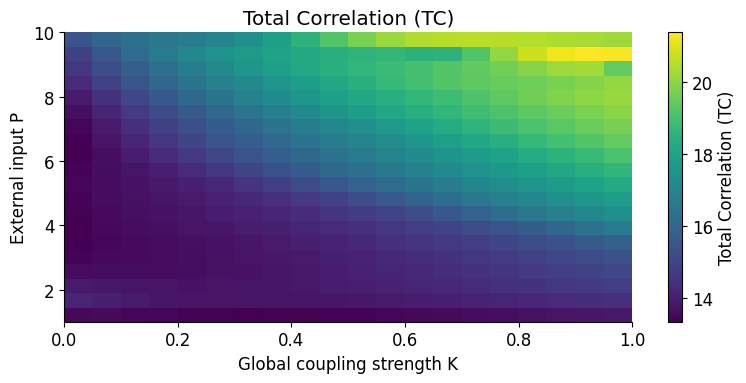

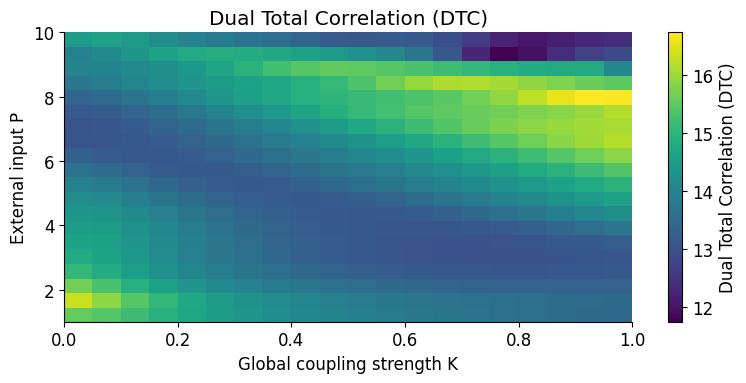

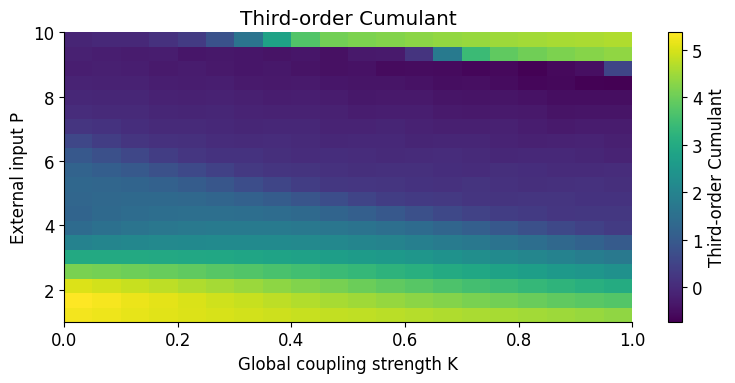

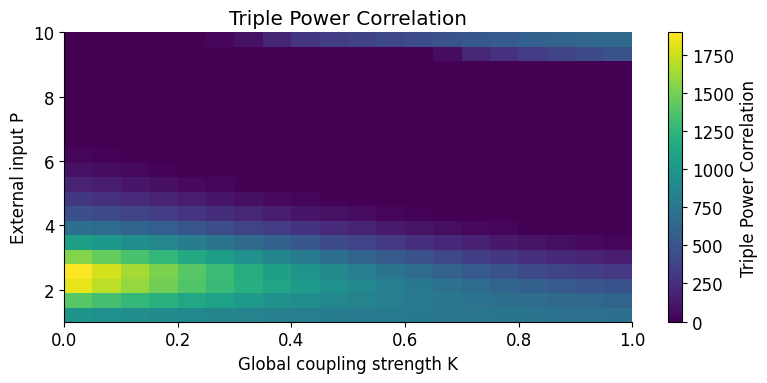

In [35]:
# -------------------------------------------------------------
# Visualization of higher-order metrics
# -------------------------------------------------------------

metrics = {
    "Total Correlation (TC)": TC_map,
    "Dual Total Correlation (DTC)": DTC_map,
    "Third-order Cumulant": Cumulant_map,
    "Triple Power Correlation": PowerCorr_map
}

for title, data in metrics.items():
    plt.figure()
    plt.imshow(
        data,
        origin="lower",
        aspect="auto",
        extent=[
            K_values.min(), K_values.max(),
            P_values.min(), P_values.max()
        ]
    )
    plt.colorbar(label=title)
    plt.xlabel("Global coupling strength K")
    plt.ylabel("External input P")
    plt.title(title)
    plt.tight_layout()
    plt.show()


## 17. Wilson–Cowan Model with Higher-Order Coupling

We study a network of three Wilson–Cowan neural mass models representing three
interacting brain regions. The goal of this section is to explore how external
input and higher-order coupling jointly shape the network dynamics.

The dynamics of node $i$ are given by:

$$
\tau_e \frac{dE_i}{dt}
=
- E_i
+ S\Big(
c_{EE} E_i
- c_{IE} I_i
+ P
+ I_i^{net}
\Big)
$$

$$
\tau_i \frac{dI_i}{dt}
=
- I_i
+ S\Big(
c_{EI} E_i
- c_{II} I_i
\Big)
$$

The activation function is a sigmoid applied elementwise:

$$
S(v) = \frac{1}{1 + e^{-a v}}
$$

The net synaptic input to the excitatory population consists solely of
higher-order (third-order) interactions:

$$
I_i^{net}
=
K_3 \sum_{j,k} T_{ijk} E_j E_k
$$

Here, $T$ is a third-order interaction tensor derived from the fixed structural
connectivity matrix $M$, and $K_3$ controls the strength of higher-order coupling.
The external input $P$ and the higher-order coupling strength $K_3$ are the
only parameters varied in the model exploration.


## 18. Network Structure and Higher-Order Interaction Tensor

The network consists of three interacting Wilson–Cowan nodes. Pairwise structural
connectivity is fixed and defined by the adjacency matrix $M$:

$$
M =
\begin{pmatrix}
0 & 1 & 1 \\
1 & 0 & 1 \\
1 & 1 & 0
\end{pmatrix}
$$

This matrix specifies which nodes are structurally connected and is kept fixed
throughout all simulations.

Higher-order interactions are encoded in a third-order tensor
$T \in \mathbb{R}^{3 \times 3 \times 3}$. The element $T_{ijk}$ represents a
triadic interaction in which the joint excitatory activity of nodes $j$ and $k$
modulates node $i$.

The tensor $T$ is constructed directly from the structural connectivity matrix
$M$ according to the following rules:

- Self-interactions are excluded.
- Only interactions between distinct nodes are allowed.
- A higher-order interaction exists only if node $i$ is structurally connected
  to both nodes $j$ and $k$ in $M$.

This construction ensures that higher-order interactions are constrained by the
underlying pairwise network structure.

In [36]:
# -------------------------------------------------------------
# Fixed pairwise structural connectivity (given)
# -------------------------------------------------------------

M = np.array([
    [0.0, 1.0, 1.0],
    [1.0, 0.0, 1.0],
    [1.0, 1.0, 0.0]
])

N_nodes = M.shape[0]


# -------------------------------------------------------------
# Higher-order interaction tensor derived from M
# -------------------------------------------------------------

T_ho = np.zeros((N_nodes, N_nodes, N_nodes))

for i in range(N_nodes):
    for j in range(N_nodes):
        for k in range(N_nodes):
            if i != j and i != k and j != k:
                if M[i, j] != 0 and M[i, k] != 0:
                    T_ho[i, j, k] = 1.0

## 19. Wilson–Cowan Dynamics with Higher-Order Coupling

We extend the Wilson–Cowan neural mass model by incorporating higher-order
(triadic) interactions between excitatory populations. Each node represents a
local excitatory–inhibitory population.

The dynamics of node $i$ are given by:

$$
\tau_e \frac{dE_i}{dt}
=
- E_i
+ S\Big(
c_{EE} E_i
- c_{IE} I_i
+ P
+ K_3 \sum_{j,k} T_{ijk} E_j E_k
\Big)
$$

$$
\tau_i \frac{dI_i}{dt}
=
- I_i
+ S\Big(
c_{EI} E_i
- c_{II} I_i
\Big)
$$

The sigmoid activation function is applied elementwise:

$$
S(v) = \frac{1}{1 + e^{-a v}}
$$

Here, $T_{ijk}$ is the higher-order interaction tensor derived from the structural
connectivity matrix, and $K_3$ controls the strength of higher-order coupling.
The external input $P$ is treated as a control parameter and is varied
systematically in the model exploration.


In [37]:
# -------------------------------------------------------------
# Wilson-Cowan dynamics with higher-order coupling
# -------------------------------------------------------------

def wc_rhs_higher_order(state, P, K3, T_ho):
    """
    Right-hand side of Wilson-Cowan equations with triadic coupling.
    
    This implements the extended Wilson-Cowan model where excitatory
    populations interact through both local connections and higher-order
    (triadic) structural motifs.
    
    Parameters
    ----------
    state : ndarray, shape (2*N,)
        Current state vector organized as [E_1,...,E_N, I_1,...,I_N].
    P : float
        External excitatory input strength (control parameter).
    K3 : float
        Higher-order coupling strength controlling triadic interactions.
    T_ho : ndarray, shape (N, N, N)
        Higher-order interaction tensor defining triadic connectivity structure.
    
    Returns
    -------
    dstate_dt : ndarray, shape (2*N,)
        Time derivative of state vector.
    
    Notes
    -----
    Implements the dynamics:
    
        tau_E * dE_i/dt = -E_i + S(c_EE*E_i - c_IE*I_i + P + K3*HO_i)
        tau_I * dI_i/dt = -I_i + S(c_EI*E_i - c_II*I_i + Q)
    
    where HO_i = sum_{j,k} T_ijk * E_j * E_k is the higher-order input.
    
    Global parameters required (must be defined externally):
    - tauE, tauI: time constants
    - cEE, cIE, cEI, cII: local connectivity weights
    - aE, aI: sigmoid slope parameters
    - Q_baseline: baseline inhibitory input
    """
    N = T_ho.shape[0]
    
    # Split state into excitatory and inhibitory components
    E = state[:N]
    I = state[N:]
    
    # Compute higher-order coupling term for each node
    # HO_i = sum over all pairs (j,k) of T_ijk * E_j * E_k
    # This captures triadic interactions between excitatory populations
    higher_order_input = np.zeros(N)
    for i in range(N):
        for j in range(N):
            for k in range(N):
                higher_order_input[i] += T_ho[i, j, k] * E[j] * E[k]
    
    # Excitatory population dynamics
    # Net input combines: self-excitation, inhibition, external drive, and triadic coupling
    #coupling = K3 * M @ E
    #input_E = cEE * E - cIE * I + P  + K3 * higher_order_input
    #dE_dt = (-E + S(input_E, aE, 2.0)) / tauE
    
    # Inhibitory population dynamics
    # Driven by excitatory input with self-inhibition
    #input_I = cEI * E - cII * I + Q_baseline
    #dI_dt = (-I + S(input_I, aI, 2.0)) / tauI

    # Coupling term (excitatory-to-excitatory)
    coupling = 0.5 * M @ E

    # Excitatory population dynamics
    dE_dt = ( -E + S(cEE * E - cEI * I + P + coupling + K3*higher_order_input)) / tauE
    # dE_dt = ( -E + S(cEE * E - cEI * I + P + K3*higher_order_input)) / tauE

    # Inhibitory population dynamics
    dI_dt = ( -I+ S(cIE * E - cII * I + Q_baseline)) / tauI
    
    return np.concatenate([dE_dt, dI_dt])


def simulate_wc_higher_order(state0, P, K3, T_ho, T, dt):
    """
    Simulate Wilson-Cowan network with higher-order coupling.
    
    Parameters
    ----------
    state0 : ndarray, shape (2*N,)
        Initial state vector.
    P : float
        External input strength.
    K3 : float
        Higher-order coupling strength.
    T_ho : ndarray, shape (N, N, N)
        Higher-order interaction tensor.
    T : float
        Total simulation time.
    dt : float
        Integration time step.
    
    Returns
    -------
    t : ndarray, shape (n_steps,)
        Time vector.
    states : ndarray, shape (n_steps, 2*N)
        Time series of state vectors.
    """
    n_steps = int(T / dt)
    t = np.linspace(0, T, n_steps)
    
    N = T_ho.shape[0]
    states = np.zeros((n_steps, 2 * N))
    states[0] = state0.copy()
    
    for i in range(1, n_steps):
        states[i] = rk4_step(wc_rhs_higher_order, states[i-1], dt, P, K3, T_ho)
    
    return t, states

SIMULATION: P = 5, K3 = 0.5
Total timesteps: 10000
Analysis timesteps: 9000

Node 0:
  E: mean=0.3431, std=0.1452, range=[0.1410, 0.6310]
  I: mean=0.5819, std=0.0757, range=[0.4652, 0.7238]

Node 1:
  E: mean=0.3429, std=0.1448, range=[0.1419, 0.6255]
  I: mean=0.5819, std=0.0756, range=[0.4652, 0.7228]

Node 2:
  E: mean=0.3433, std=0.1456, range=[0.1402, 0.6369]
  I: mean=0.5819, std=0.0758, range=[0.4653, 0.7246]


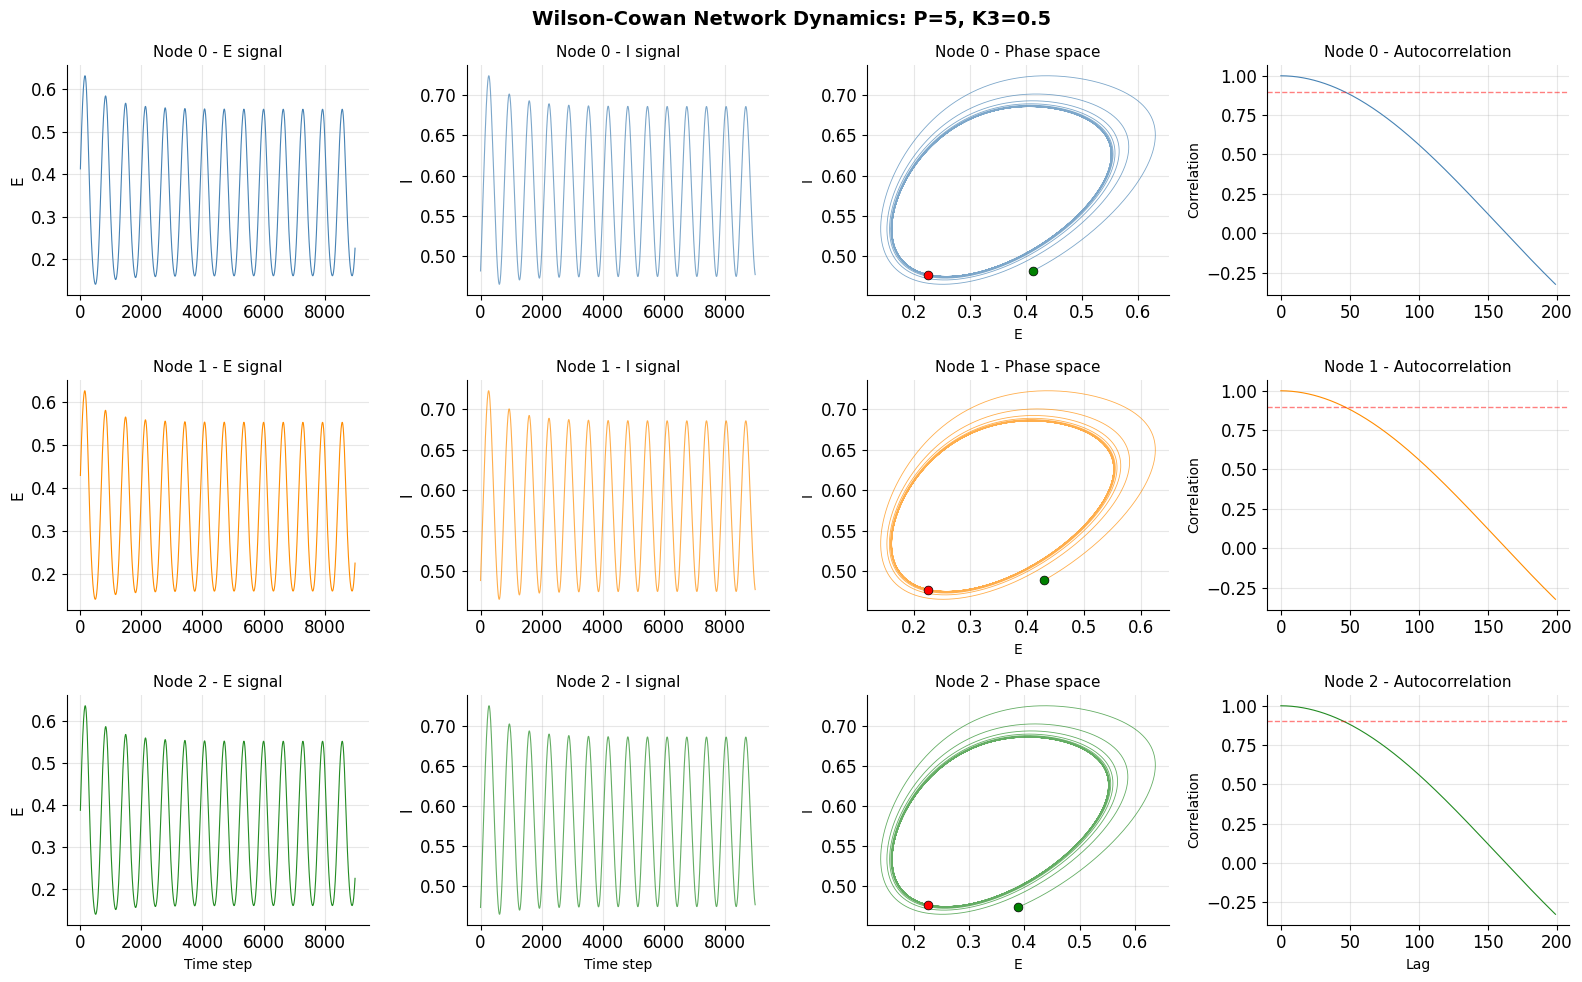

In [38]:
# -------------------------------------------------------------
# Simple single simulation with visualization for all 3 nodes
# -------------------------------------------------------------

# Set parameters
#P_sim = 1.32   # External input strength
#K3_sim = 0.7  # Higher-order coupling strength
P_sim = 5   # External input strength
K3_sim = 0.5  # Higher-order coupling strength



# Initial conditions
state0 = 0.1 * np.random.randn(2 * N_nodes)

print("=" * 60)
print(f"SIMULATION: P = {P_sim}, K3 = {K3_sim}")
print("=" * 60)

# Run simulation
t, states = simulate_wc_higher_order(
    state0=state0,
    P=P_sim,
    K3=K3_sim,
    T_ho=T_ho,
    T=T,
    dt=dt
)

# Remove transient (first half)
#start_idx = len(states) // 2

# Remove transient (first 1 second)
transient_time = 1.0          # seconds
transient_steps = int(transient_time / dt)

start_idx = transient_steps

# Extract excitatory and inhibitory signals
E = states[start_idx:, :N_nodes]
I = states[start_idx:, N_nodes:]

print(f"Total timesteps: {len(states)}")
print(f"Analysis timesteps: {len(E)}")

# Visualization for all 3 nodes
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

colors = ['steelblue', 'darkorange', 'forestgreen']
node_labels = ['Node 0', 'Node 1', 'Node 2']

for node in range(N_nodes):
    E_node = E[:, node]
    I_node = I[:, node]
    
    # Statistics
    print(f"\n{node_labels[node]}:")
    print(f"  E: mean={E_node.mean():.4f}, std={np.std(E_node):.4f}, range=[{E_node.min():.4f}, {E_node.max():.4f}]")
    print(f"  I: mean={I_node.mean():.4f}, std={np.std(I_node):.4f}, range=[{I_node.min():.4f}, {I_node.max():.4f}]")
    
    # Excitatory time series
    axes[node, 0].plot(E_node, linewidth=0.8, color=colors[node])
    axes[node, 0].set_ylabel("E", fontsize=11)
    axes[node, 0].set_title(f"{node_labels[node]} - E signal", fontsize=11)
    axes[node, 0].grid(True, alpha=0.3)
    if node == 2:
        axes[node, 0].set_xlabel("Time step", fontsize=10)
    
    # Inhibitory time series
    axes[node, 1].plot(I_node, linewidth=0.8, color=colors[node], alpha=0.7)
    axes[node, 1].set_ylabel("I", fontsize=11)
    axes[node, 1].set_title(f"{node_labels[node]} - I signal", fontsize=11)
    axes[node, 1].grid(True, alpha=0.3)
    if node == 2:
        axes[node, 1].set_xlabel("Time step", fontsize=10)
    
    # Phase space (E vs I)
    axes[node, 2].plot(E_node, I_node, alpha=0.7, linewidth=0.6, color=colors[node])
    axes[node, 2].scatter(E_node[0], I_node[0], c='green', s=40, zorder=5, edgecolors='black', linewidths=0.5)
    axes[node, 2].scatter(E_node[-1], I_node[-1], c='red', s=40, zorder=5, edgecolors='black', linewidths=0.5)
    axes[node, 2].set_xlabel("E", fontsize=10)
    axes[node, 2].set_ylabel("I", fontsize=10)
    axes[node, 2].set_title(f"{node_labels[node]} - Phase space", fontsize=11)
    axes[node, 2].grid(True, alpha=0.3)
    
    # Autocorrelation
    E_centered = E_node - np.mean(E_node)
    if np.std(E_centered) > 1e-6:
        autocorr = np.correlate(E_centered, E_centered, mode='full')
        autocorr = autocorr[len(autocorr)//2:]
        autocorr = autocorr / autocorr[0]
        
        axes[node, 3].plot(autocorr[:min(200, len(autocorr))], linewidth=0.8, color=colors[node])
        axes[node, 3].axhline(y=0.9, color='r', linestyle='--', alpha=0.5, linewidth=1)
        axes[node, 3].set_ylabel("Correlation", fontsize=10)
        axes[node, 3].set_title(f"{node_labels[node]} - Autocorrelation", fontsize=11)
        axes[node, 3].grid(True, alpha=0.3)
        if node == 2:
            axes[node, 3].set_xlabel("Lag", fontsize=10)

plt.suptitle(f"Wilson-Cowan Network Dynamics: P={P_sim}, K3={K3_sim}", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 20. Model Exploration: Oscillatory Regimes in the $(P, K_3)$ Plane

We explore the dynamical regimes of the Wilson–Cowan model with higher-order
coupling by systematically varying the external input $P$ and the higher-order
coupling strength $K_3$.

The model consists of three coupled Wilson–Cowan nodes, with higher-order
interactions defined by a third-order tensor derived from the structural
connectivity matrix:

$$
M =
\begin{pmatrix}
0 & 1 & 1 \\
1 & 0 & 1 \\
1 & 1 & 0
\end{pmatrix}
$$

The parameters are varied as follows:

$$
P \in [1, 10], \qquad K_3 \in [0, 1]
$$

For each parameter pair $(P, K_3)$, the system is numerically integrated and
the presence of oscillatory activity is assessed from the excitatory time
series. The resulting phase diagram reveals the regions in parameter space
where sustained oscillations emerge due to higher-order interactions.


In [39]:
# -------------------------------------------------------------
# Parameter search using Poincaré method for limit cycle detection
# -------------------------------------------------------------

def search_limit_cycle_parameters(T_ho, P_range, K3_range, 
                                   T_sim=50.0, dt=0.001,
                                   threshold_ratio=0.05,
                                   period_cv_threshold=0.10):
    """
    Systematic search for parameter combinations that produce limit cycles.
    Uses Poincaré section method for rigorous detection.
    
    Parameters
    ----------
    T_ho : ndarray, shape (N, N, N)
        Higher-order interaction tensor.
    P_range : ndarray
        Array of P values to test.
    K3_range : ndarray
        Array of K3 values to test.
    T_sim : float
        Simulation time for each parameter combination.
    dt : float
        Integration time step.
    threshold_ratio : float
        Poincaré dispersion threshold for limit cycle detection.
    period_cv_threshold : float
        Period consistency threshold for limit cycle detection.
    
    Returns
    -------
    results : dict
        Dictionary containing detection results and optimal parameters.
    """
    
    N_nodes = T_ho.shape[0]
    n_P = len(P_range)
    n_K3 = len(K3_range)
    
    # Storage arrays
    limit_cycle_map = np.zeros((n_P, n_K3))
    variance_map = np.zeros((n_P, n_K3))
    dispersion_map = np.full((n_P, n_K3), np.inf)
    period_map = np.zeros((n_P, n_K3))
    
    # Fixed initial condition for consistency
    state0 = 0.1 * np.random.randn(2 * N_nodes)
    
    n_steps = int(T_sim / dt)
    transient_idx = int(0.5 * n_steps)
    
    print(f"Searching for limit cycles using Poincaré method:")
    print(f"  P range: {P_range[0]:.2f} to {P_range[-1]:.2f} ({n_P} values)")
    print(f"  K3 range: {K3_range[0]:.2f} to {K3_range[-1]:.2f} ({n_K3} values)")
    print(f"  Total simulations: {n_P * n_K3}")
    print(f"  Simulation time: {T_sim} time units")
    print(f"  Detection criteria: dispersion < {threshold_ratio}, period_cv < {period_cv_threshold}")
    print()
    
    best_dispersion = np.inf
    best_P = None
    best_K3 = None
    n_limit_cycles = 0
    
    # Systematic parameter sweep
    for i, P_val in enumerate(P_range):
        for j, K3_val in enumerate(K3_range):
            
            # Run simulation
            t, states = simulate_wc_higher_order(
                state0, P_val, K3_val, T_ho, T_sim, dt
            )
            
            # Extract post-transient data
            E = states[transient_idx:, :N_nodes]
            I = states[transient_idx:, N_nodes:]
            
            # Calculate variance for all nodes
            node_variances = [np.var(E[:, node]) for node in range(N_nodes)]
            variance_map[i, j] = np.mean(node_variances)
            
            # Test each node for limit cycle using Poincaré method
            limit_cycle_detected = False
            best_node_dispersion = np.inf
            best_node_period = None
            
            for node in range(N_nodes):
                E_node = E[:, node]
                I_node = I[:, node]
                
                # Skip if signal is too flat
                if np.std(E_node) < 1e-5:
                    continue
                
                # Apply Poincaré section method
                is_lc, period, dispersion, n_crossings = detect_limit_cycle_poincare(
                    E_node, I_node, dt,
                    threshold_ratio=threshold_ratio,
                    period_cv_threshold=period_cv_threshold
                )
                
                # Track best dispersion across nodes
                if dispersion < best_node_dispersion:
                    best_node_dispersion = dispersion
                    best_node_period = period
                
                # Mark if any node has limit cycle
                if is_lc:
                    limit_cycle_detected = True
            
            # Store results for this parameter combination
            dispersion_map[i, j] = best_node_dispersion
            
            if limit_cycle_detected:
                limit_cycle_map[i, j] = 1
                n_limit_cycles += 1
                period_map[i, j] = best_node_period if best_node_period else 0
                
                # Track best limit cycle (lowest dispersion = most stable)
                if best_node_dispersion < best_dispersion:
                    best_dispersion = best_node_dispersion
                    best_P = P_val
                    best_K3 = K3_val
        
        # Progress update
        if (i + 1) % 5 == 0 or i == n_P - 1:
            current_lc = int(np.sum(limit_cycle_map[:i+1, :]))
            print(f"Progress: {i+1}/{n_P} ({100*(i+1)/n_P:.0f}%) - "
                  f"Limit cycles found: {current_lc}")
    
    # Summary
    print(f"\n{'='*60}")
    print(f"LIMIT CYCLE SEARCH RESULTS")
    print(f"{'='*60}")
    print(f"Limit cycles detected: {n_limit_cycles}/{n_P * n_K3}")
    print(f"Percentage: {100*n_limit_cycles/(n_P * n_K3):.1f}%")
    
    if best_P is not None:
        print(f"\nBest limit cycle parameters (lowest dispersion):")
        print(f"  P* = {best_P:.3f}")
        print(f"  K3* = {best_K3:.3f}")
        print(f"  Dispersion = {best_dispersion:.6f}")
        if period_map[np.where((P_range == best_P))[0][0], 
                      np.where((K3_range == best_K3))[0][0]] > 0:
            print(f"  Period = {period_map[np.where((P_range == best_P))[0][0], np.where((K3_range == best_K3))[0][0]]:.4f} time units")
    else:
        print(f"\nNo limit cycles detected.")
        print(f"Best variance found: {variance_map.max():.6f}")
        print(f"Best dispersion found: {dispersion_map.min():.6f}")
    
    return {
        'limit_cycle_map': limit_cycle_map,
        'variance_map': variance_map,
        'dispersion_map': dispersion_map,
        'period_map': period_map,
        'best_params': (best_P, best_K3) if best_P else None,
        'best_dispersion': best_dispersion,
        'P_range': P_range,
        'K3_range': K3_range,
        'n_limit_cycles': n_limit_cycles
    }

Searching for limit cycles using Poincaré method:
  P range: 1.00 to 10.00 (20 values)
  K3 range: 0.00 to 1.00 (20 values)
  Total simulations: 400
  Simulation time: 50.0 time units
  Detection criteria: dispersion < 0.05, period_cv < 0.1

Progress: 5/20 (25%) - Limit cycles found: 0
Progress: 10/20 (50%) - Limit cycles found: 54
Progress: 15/20 (75%) - Limit cycles found: 154
Progress: 20/20 (100%) - Limit cycles found: 212

LIMIT CYCLE SEARCH RESULTS
Limit cycles detected: 212/400
Percentage: 53.0%

Best limit cycle parameters (lowest dispersion):
  P* = 8.579
  K3* = 1.000
  Dispersion = 0.000000
  Period = 3.3080 time units


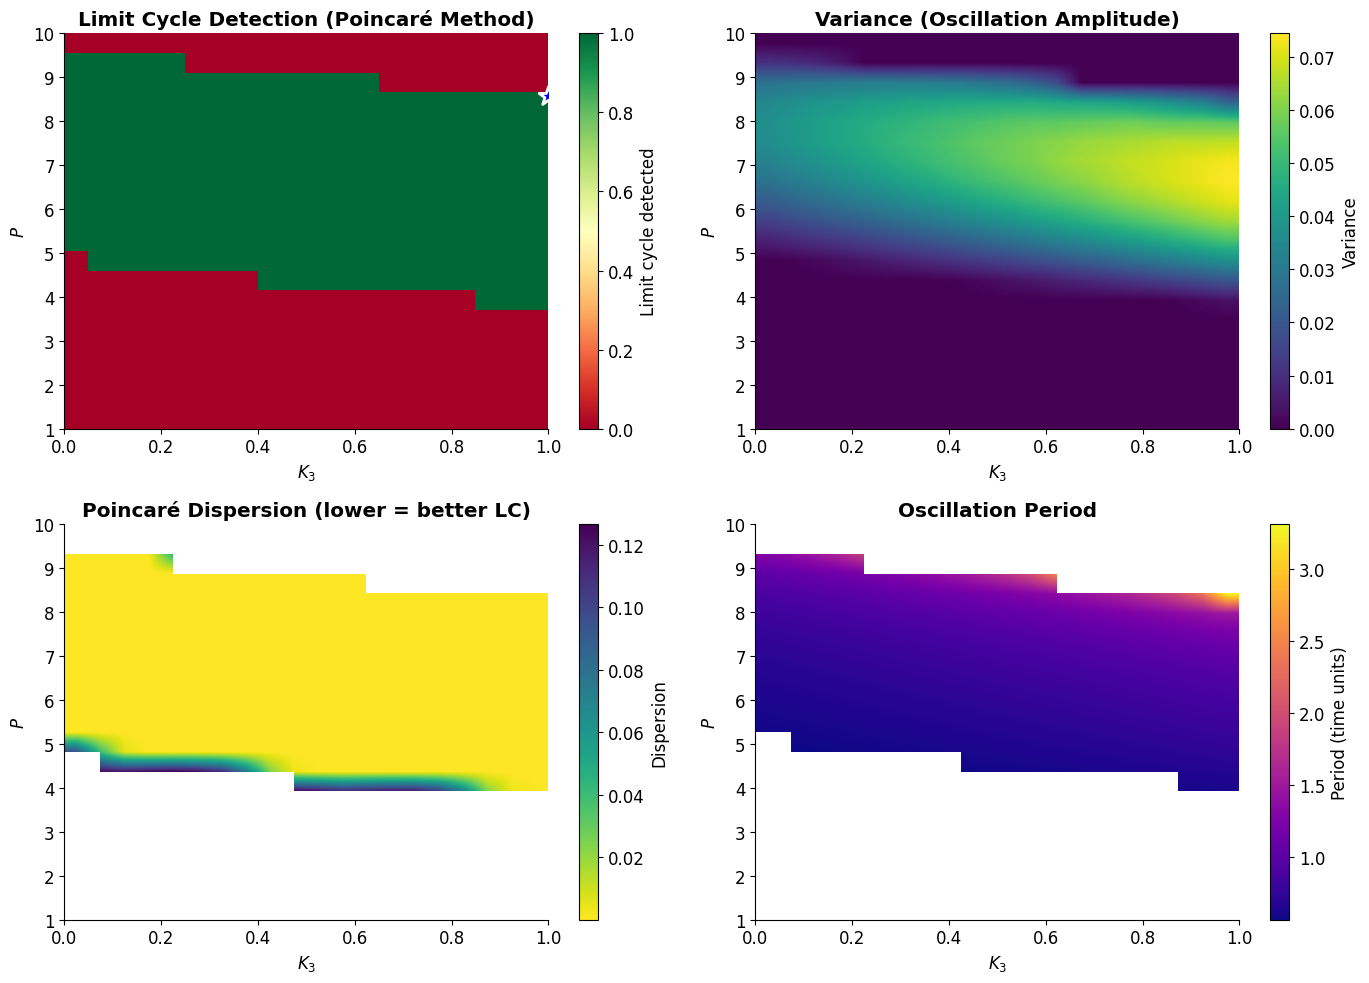


RECOMMENDED PARAMETERS FOR LIMIT CYCLE
P = 8.579
K3 = 1.000


In [40]:
# -------------------------------------------------------------
# Execute limit cycle search
# -------------------------------------------------------------

P_search = np.linspace(1.0, 10.0, 20)
K3_search = np.linspace(0.0, 1.0, 20)

results = search_limit_cycle_parameters(
    T_ho=T_ho,
    P_range=P_search,
    K3_range=K3_search,
    T_sim=50.0,
    dt=dt,
    threshold_ratio=0.05,
    period_cv_threshold=0.10
)

# -------------------------------------------------------------
# Visualization
# -------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Limit cycle detection map
im1 = axes[0, 0].imshow(
    results['limit_cycle_map'],
    origin='lower',
    aspect='auto',
    extent=[K3_search[0], K3_search[-1], P_search[0], P_search[-1]],
    cmap='RdYlGn',
    interpolation='nearest'
)
axes[0, 0].set_xlabel(r"$K_3$", fontsize=12)
axes[0, 0].set_ylabel(r"$P$", fontsize=12)
axes[0, 0].set_title("Limit Cycle Detection (Poincaré Method)", fontweight='bold')
plt.colorbar(im1, ax=axes[0, 0], label="Limit cycle detected")

if results['best_params']:
    best_P, best_K3 = results['best_params']
    axes[0, 0].scatter(best_K3, best_P, c='blue', s=200, marker='*',
                      edgecolors='white', linewidths=2, zorder=10)

# Variance map
im2 = axes[0, 1].imshow(
    results['variance_map'],
    origin='lower',
    aspect='auto',
    extent=[K3_search[0], K3_search[-1], P_search[0], P_search[-1]],
    cmap='viridis',
    interpolation='bilinear'
)
axes[0, 1].set_xlabel(r"$K_3$", fontsize=12)
axes[0, 1].set_ylabel(r"$P$", fontsize=12)
axes[0, 1].set_title("Variance (Oscillation Amplitude)", fontweight='bold')
plt.colorbar(im2, ax=axes[0, 1], label="Variance")

# Dispersion map (lower = better limit cycle)
disp_plot = np.copy(results['dispersion_map'])
disp_plot[disp_plot == np.inf] = np.nan  # Hide non-oscillatory regions

im3 = axes[1, 0].imshow(
    disp_plot,
    origin='lower',
    aspect='auto',
    extent=[K3_search[0], K3_search[-1], P_search[0], P_search[-1]],
    cmap='viridis_r',
    interpolation='bilinear'
)
axes[1, 0].set_xlabel(r"$K_3$", fontsize=12)
axes[1, 0].set_ylabel(r"$P$", fontsize=12)
axes[1, 0].set_title("Poincaré Dispersion (lower = better LC)", fontweight='bold')
plt.colorbar(im3, ax=axes[1, 0], label="Dispersion")

# Period map
period_plot = np.copy(results['period_map'])
period_plot[period_plot == 0] = np.nan

im4 = axes[1, 1].imshow(
    period_plot,
    origin='lower',
    aspect='auto',
    extent=[K3_search[0], K3_search[-1], P_search[0], P_search[-1]],
    cmap='plasma',
    interpolation='bilinear'
)
axes[1, 1].set_xlabel(r"$K_3$", fontsize=12)
axes[1, 1].set_ylabel(r"$P$", fontsize=12)
axes[1, 1].set_title("Oscillation Period", fontweight='bold')
plt.colorbar(im4, ax=axes[1, 1], label="Period (time units)")

plt.tight_layout()
plt.show()

# Final recommendation
if results['best_params']:
    print(f"\n{'='*60}")
    print(f"RECOMMENDED PARAMETERS FOR LIMIT CYCLE")
    print(f"{'='*60}")
    print(f"P = {results['best_params'][0]:.3f}")
    print(f"K3 = {results['best_params'][1]:.3f}")

## 21. Higher-Order Metrics on the $(P, K_3)$ Phase Diagram

To characterize the emergence of higher-order interactions beyond pairwise
coupling, we compute several higher-order and information-theoretic metrics
from the simulated excitatory activity of the three-node Wilson–Cowan network.

For each parameter pair $(P, K_3)$, the following metrics are evaluated from
the post-transient excitatory time series:

- Third-order cumulant (coskewness)
- Total Correlation (TC)
- Dual Total Correlation (DTC)
- Triple Power Correlation

All metrics are computed on z-scored signals and quantify deviations from
purely pairwise Gaussian interactions. Their dependence on $(P, K_3)$ reveals
regions where higher-order interactions become dominant.


In [48]:
# -------------------------------------------------------------
# Containers for higher-order metrics
# -------------------------------------------------------------

entropy_map = np.zeros((len(P_search), len(K3_search)))
cumulant_map = np.zeros_like(entropy_map)
TC_map = np.zeros_like(entropy_map)
DTC_map = np.zeros_like(entropy_map)
powercorr_map = np.zeros_like(entropy_map)
n_steps = int(50.0 / dt)
transient = int(0.5 * n_steps)

state0 = 0.1 * np.random.randn(2 * N_nodes)

# -------------------------------------------------------------
# Loop over parameter space
# -------------------------------------------------------------

for i, P in enumerate(P_search):
    for j, K3 in enumerate(K3_search):

        state = state0.copy()
        E_history = []

        for _ in range(n_steps):
            #t, state = simulate_wc_higher_order(state, P, K3, T_ho, T, dt)
            #state = rk4_step(wilson_cowan_rhs_ho, state, dt, P, K3, T_ho)
            state = rk4_step(wc_rhs_higher_order, state, dt, P, K3, T_ho)
            E_history.append(state[:N_nodes])

        E_history = np.array(E_history)[transient:]

        # -----------------------------------------------------
        # Z-score excitatory signals
        # -----------------------------------------------------

        X = (E_history - E_history.mean(axis=0)) / E_history.std(axis=0)

        # -----------------------------------------------------
        # Higher-order metrics
        # -----------------------------------------------------

        cumulant_map[i, j] = cumulants(X)

        Sigma = np.cov(X.T)

        entropy_map[i, j] = entropy_gauss(Sigma)
        TC_map[i, j] = TC_gauss(Sigma)
        DTC_map[i, j] = DTC_gauss(Sigma)

        powercorr_map[i, j] = powercorr(X)

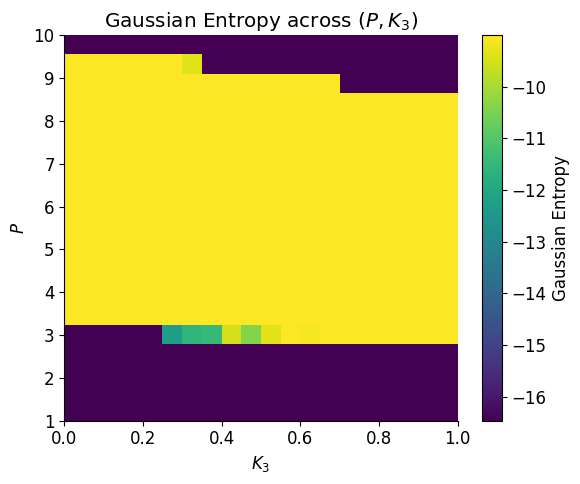

In [49]:
plt.figure(figsize=(6, 5))
plt.imshow(
    entropy_map,
    origin="lower",
    aspect="auto",
    extent=[K3_search[0], K3_search[-1], P_search[0], P_search[-1]]
)
plt.colorbar(label="Gaussian Entropy")
plt.xlabel(r"$K_3$")
plt.ylabel(r"$P$")
plt.title("Gaussian Entropy across $(P, K_3)$")
plt.tight_layout()
plt.show()

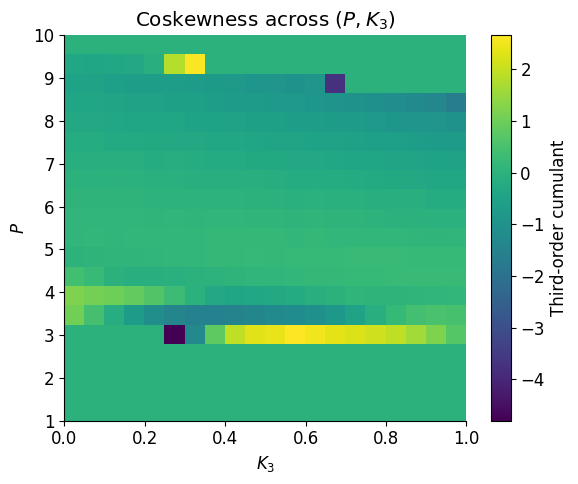

In [50]:
plt.figure(figsize=(6, 5))
plt.imshow(
    cumulant_map,
    origin="lower",
    aspect="auto",
    extent=[K3_search[0], K3_search[-1], P_search[0], P_search[-1]]
)
plt.colorbar(label="Third-order cumulant")
plt.xlabel(r"$K_3$")
plt.ylabel(r"$P$")
plt.title("Coskewness across $(P, K_3)$")
plt.tight_layout()
plt.show()


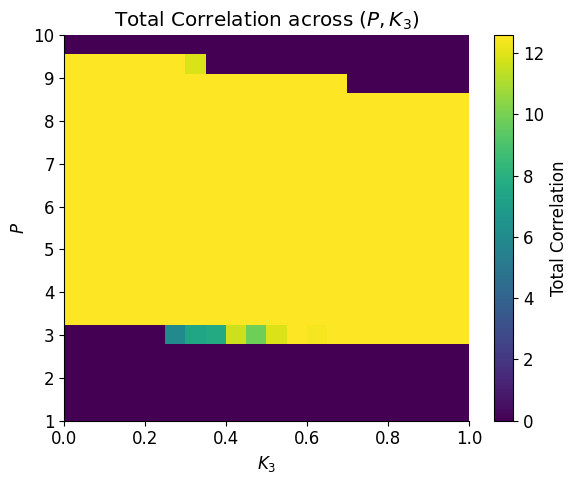

In [51]:
plt.figure(figsize=(6, 5))
plt.imshow(
    TC_map,
    origin="lower",
    aspect="auto",
    extent=[K3_search[0], K3_search[-1], P_search[0], P_search[-1]]
)
plt.colorbar(label="Total Correlation")
plt.xlabel(r"$K_3$")
plt.ylabel(r"$P$")
plt.title("Total Correlation across $(P, K_3)$")
plt.tight_layout()
plt.show()


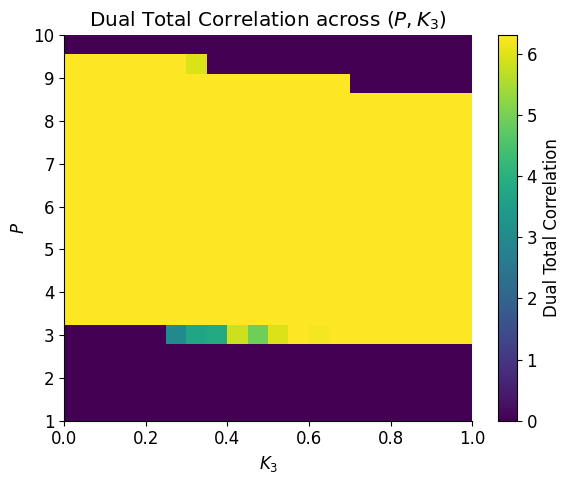

In [52]:
plt.figure(figsize=(6, 5))
plt.imshow(
    DTC_map,
    origin="lower",
    aspect="auto",
    extent=[K3_search[0], K3_search[-1], P_search[0], P_search[-1]]
)
plt.colorbar(label="Dual Total Correlation")
plt.xlabel(r"$K_3$")
plt.ylabel(r"$P$")
plt.title("Dual Total Correlation across $(P, K_3)$")
plt.tight_layout()
plt.show()


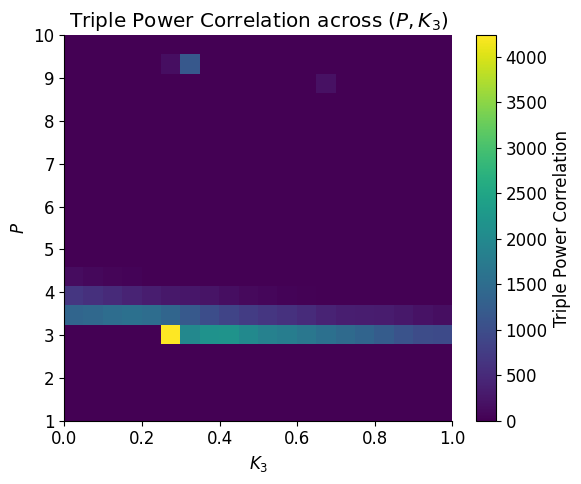

In [53]:
plt.figure(figsize=(6, 5))
plt.imshow(
    powercorr_map,
    origin="lower",
    aspect="auto",
    extent=[K3_search[0], K3_search[-1], P_search[0], P_search[-1]]
)
plt.colorbar(label="Triple Power Correlation")
plt.xlabel(r"$K_3$")
plt.ylabel(r"$P$")
plt.title("Triple Power Correlation across $(P, K_3)$")
plt.tight_layout()
plt.show()


# Wilson-Cowan Neural Mass Model: Pairwise and Higher-Order Dynamics with Stochastic Noise

---
## **1. Introduction**
This notebook implements the **Wilson-Cowan neural mass model** in two configurations:
1. **Pairwise interactions** (standard Wilson-Cowan).
2. **Higher-order (triadic) interactions** between excitatory populations.

Additionally, we incorporate **stochastic noise** in the excitatory population using the **Euler-Maruyama method** to simulate biological variability.

---

## **2. Mathematical Formulation**

### **2.1. Pairwise Interactions**
The dynamics of node \(i\) are given by:

#### **Excitatory Population:**
$$
\tau_E \frac{dE_i}{dt} = -E_i + S\left(c_{EE} E_i - c_{IE} I_i + P + K \sum_{j} M_{ij} E_j\right)
$$

#### **Inhibitory Population:**
$$
\tau_I \frac{dI_i}{dt} = -I_i + S\left(c_{IE} E_i - c_{II} I_i + Q\right)
$$

---

### **2.2. Higher-Order Interactions**
The dynamics of node \(i\) with higher-order interactions are:

#### **Excitatory Population:**
$$
\tau_E \frac{dE_i}{dt} = -E_i + S\left(c_{EE} E_i - c_{IE} I_i + P + K_3 \sum_{j,k} T_{ijk} E_j E_k\right)
$$

#### **Inhibitory Population:**
$$
\tau_I \frac{dI_i}{dt} = -I_i + S\left(c_{EI} E_i - c_{II} I_i\right)
$$

---

### **2.3. Stochastic Dynamics (Euler-Maruyama)**
To include biological noise, we extend the excitatory population dynamics using the **Euler-Maruyama method**:

$$
E_i(t + \Delta t) = E_i(t) + \frac{\Delta t}{\tau_E} \left(-E_i(t) + S(\text{input})\right) + \frac{\sigma_E \sqrt{\Delta t}}{\tau_E} \xi_i
$$

- $(\sigma_E)$: Noise intensity for the excitatory population.
- $(\xi_i \sim \mathcal{N}(0, 1))$: Gaussian white noise.


In [ ]:
def euler_maruyama_step(state, dt, rhs_function, *args, sigma_E=0.01):
    """
    Euler-Maruyama step for Wilson-Cowan with noise in E.

    Parameters:
    -----------
    state : ndarray, shape (2*N,)
        Current state: [E_1, ..., E_N, I_1, ..., I_N].
    dt : float
        Time step.
    rhs_function : function
        Function that computes the deterministic RHS.
    *args : tuple
        Additional arguments for rhs_function.
    sigma_E : float, optional
        Noise intensity for E (default: 0.01).

    Returns:
    --------
    new_state : ndarray, shape (2*N,)
        State at the next time step.
    """
    N = len(state) // 2
    E = state[:N]
    I = state[N:]

    # Deterministic term
    dstate_dt = rhs_function(state, *args)
    dE_dt = dstate_dt[:N]
    dI_dt = dstate_dt[N:]

    # Stochastic term for E
    dW_E = np.random.randn(N) * np.sqrt(dt)

    # Update E and I
    E_new = E + dE_dt * dt + (sigma_E * dW_E) / tauE
    I_new = I + dI_dt * dt  # No noise for I

    return np.concatenate([E_new, I_new])



def simulate_wc_stochastic(state0, P, K, M, T, dt, sigma_E=0.01, higher_order=False, T_ho=None):
    """
    Simula el modelo Wilson-Cowan con ruido en E usando Euler-Maruyama.

    Parámetros:
    -----------
    state0 : ndarray, shape (2*N,)
        Estado inicial.
    P : float
        Entrada excitatoria externa.
    K : float
        Fuerza de acoplamiento global (para interacciones de pares).
    M : ndarray, shape (N, N)
        Matriz de adyacencia (para interacciones de pares).
    T : float
        Tiempo total de simulación.
    dt : float
        Paso de tiempo.
    sigma_E : float, opcional
        Intensidad del ruido para E (default: 0.01).
    higher_order : bool, opcional
        Si es True, usa interacciones de alto orden (default: False).
    T_ho : ndarray, shape (N, N, N), opcional
        Tensor de interacciones de alto orden (requerido si higher_order=True).

    Retorna:
    --------
    t : ndarray, shape (n_steps,)
        Vector de tiempo.
    states : ndarray, shape (n_steps, 2*N)
        Serie temporal de estados.
    """
    n_steps = int(T / dt)
    N = M.shape[0]
    states = np.zeros((n_steps, 2 * N))
    states[0] = state0
    t = np.linspace(0, T, n_steps)

    for i in range(1, n_steps):
        # Calcular el término determinístico
        if higher_order:
            if T_ho is None:
                raise ValueError("T_ho debe ser proporcionado para interacciones de alto orden.")
            dstate_dt = wc_rhs_higher_order(states[i-1], P, K, T_ho)
        else:
            dstate_dt = wc_rhs(states[i-1], P, K, M)

        # Separar las derivadas de E e I
        dE_dt = dstate_dt[:N]
        dI_dt = dstate_dt[N:]

        # Agregar ruido solo a E
        dW_E = np.random.randn(N) * np.sqrt(dt)
        E_new = states[i-1, :N] + dE_dt * dt + (sigma_E * dW_E) / tauE
        I_new = states[i-1, N:] + dI_dt * dt  # Sin ruido para I

        # Actualizar el estado
        states[i] = np.concatenate([E_new, I_new])

    return t, states


def simulate_wc_higher_order_stochastic(state0, P, K3, T_ho, T, dt, sigma_E=0.01):
    """
    Simulate Wilson-Cowan network with higher-order coupling and stochastic noise in E.

    Parameters
    ----------
    state0 : ndarray, shape (2*N,)
        Initial state vector.
    P : float
        External input strength.
    K3 : float
        Higher-order coupling strength.
    T_ho : ndarray, shape (N, N, N)
        Higher-order interaction tensor.
    T : float
        Total simulation time.
    dt : float
        Integration time step.
    sigma_E : float, optional
        Noise intensity for E (default: 0.01).

    Returns
    -------
    t : ndarray, shape (n_steps,)
        Time vector.
    states : ndarray, shape (n_steps, 2*N)
        Time series of state vectors.
    """
    n_steps = int(T / dt)
    t = np.linspace(0, T, n_steps)

    N = T_ho.shape[0]
    states = np.zeros((n_steps, 2 * N))
    states[0] = state0.copy()

    for i in range(1, n_steps):
        # Calculate the deterministic part
        dstate_dt = wc_rhs_higher_order(states[i-1], P, K3, T_ho)

        # Split into E and I derivatives
        dE_dt = dstate_dt[:N]
        dI_dt = dstate_dt[N:]

        # Add stochastic noise to E
        dW_E = np.random.randn(N) * np.sqrt(dt)
        E_new = states[i-1, :N] + dE_dt * dt + (sigma_E * dW_E) / tauE
        I_new = states[i-1, N:] + dI_dt * dt  # No noise for I

        # Update the state
        states[i] = np.concatenate([E_new, I_new])

    return t, states


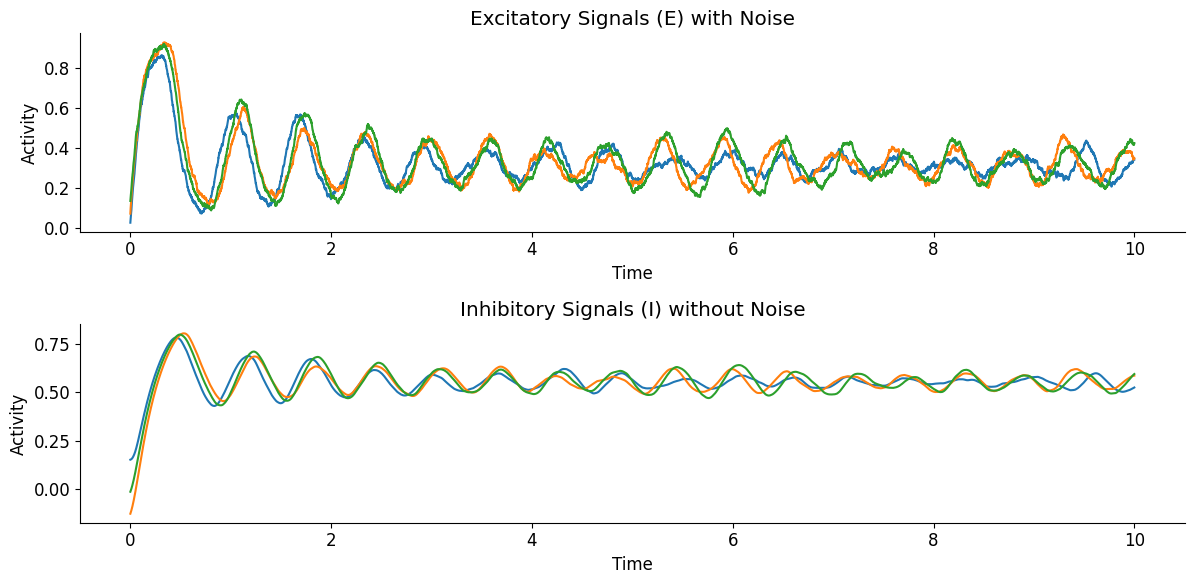

In [61]:
# Parámetros de simulación
P_sim = 5.0
K_sim = 0.5
sigma_E = 0.01

# Estado inicial
state0 = 0.1 * np.random.randn(2 * N_nodes)

# Simulación con interacciones de pares y ruido en E
t, states = simulate_wc_stochastic(
    state0=state0,
    P=P_sim,
    K=K_sim,
    M=M,
    T=T,
    dt=dt,
    sigma_E=sigma_E,
    higher_order=False
)

# Extraer señales excitatorias e inhibitorias
E = states[:, :N_nodes]
I = states[:, N_nodes:]

# Visualización
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, E)
plt.title("Excitatory Signals (E) with Noise")
plt.xlabel("Time")
plt.ylabel("Activity")

plt.subplot(2, 1, 2)
plt.plot(t, I)
plt.title("Inhibitory Signals (I) without Noise")
plt.xlabel("Time")
plt.ylabel("Activity")

plt.tight_layout()
plt.show()


SIMULATION: P = 5, K3 = 0.5
Total timesteps: 10000
Analysis timesteps: 9000

Node 0:
  E: mean=0.3240, std=0.1063, range=[0.1234, 0.6000]
  I: mean=0.5620, std=0.0543, range=[0.4456, 0.6852]

Node 1:
  E: mean=0.3184, std=0.0851, range=[0.1495, 0.5673]
  I: mean=0.5578, std=0.0445, range=[0.4706, 0.6689]

Node 2:
  E: mean=0.3210, std=0.1023, range=[0.1326, 0.5652]
  I: mean=0.5610, std=0.0539, range=[0.4542, 0.6836]


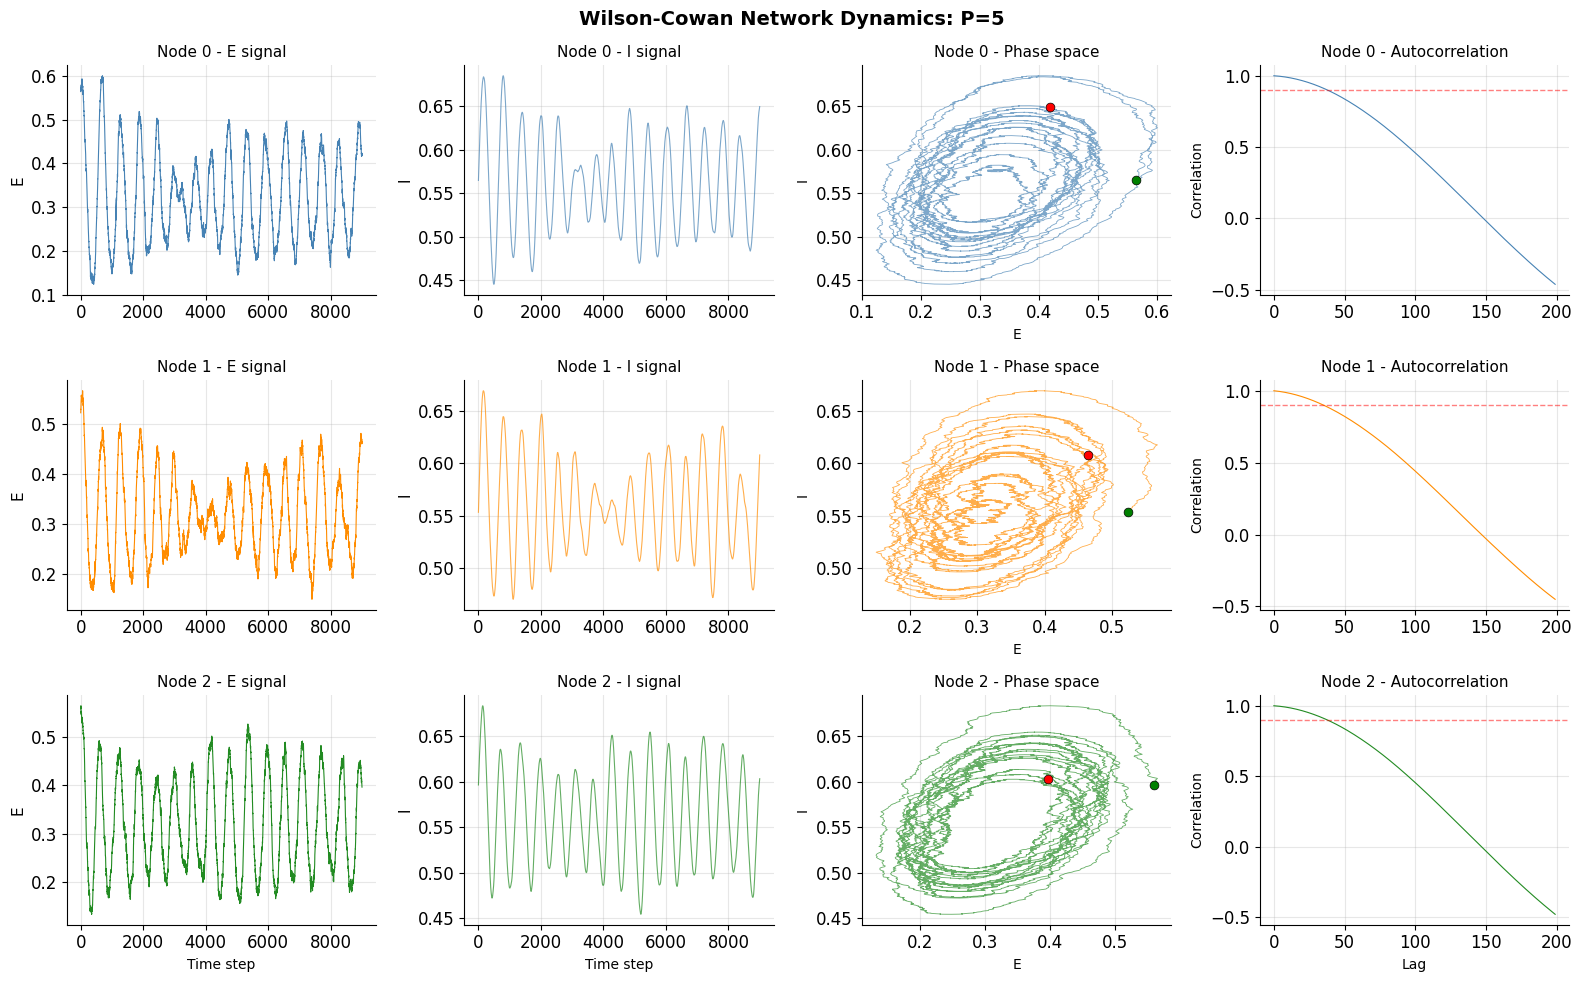

In [77]:
# -------------------------------------------------------------
# Simple single simulation with visualization for all 3 nodes
# -------------------------------------------------------------

# Set parameters
#P_sim = 1.32   # External input strength
#K3_sim = 0.7  # Higher-order coupling strength
P_sim = 5   # External input strength
K3_sim = 0.5  # Higher-order coupling strength



# Initial conditions
state0 = 0.1 * np.random.randn(2 * N_nodes)

print("=" * 60)
print(f"SIMULATION: P = {P_sim}, K3 = {K3_sim}")
print("=" * 60)

# Run simulation
t, states = simulate_wc_stochastic(
                    state0=state0,
                    P=P_sim,
                    K=K_sim,
                    M=M,
                    T=T,
                    dt=dt,
                    sigma_E=sigma_E,
                    higher_order=False
                )

# Remove transient (first half)
#start_idx = len(states) // 2

# Remove transient (first 1 second)
transient_time = 1.0          # seconds
transient_steps = int(transient_time / dt)

start_idx = transient_steps

# Extract excitatory and inhibitory signals
E = states[start_idx:, :N_nodes]
I = states[start_idx:, N_nodes:]

print(f"Total timesteps: {len(states)}")
print(f"Analysis timesteps: {len(E)}")

# Visualization for all 3 nodes
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

colors = ['steelblue', 'darkorange', 'forestgreen']
node_labels = ['Node 0', 'Node 1', 'Node 2']

for node in range(N_nodes):
    E_node = E[:, node]
    I_node = I[:, node]
    
    # Statistics
    print(f"\n{node_labels[node]}:")
    print(f"  E: mean={E_node.mean():.4f}, std={np.std(E_node):.4f}, range=[{E_node.min():.4f}, {E_node.max():.4f}]")
    print(f"  I: mean={I_node.mean():.4f}, std={np.std(I_node):.4f}, range=[{I_node.min():.4f}, {I_node.max():.4f}]")
    
    # Excitatory time series
    axes[node, 0].plot(E_node, linewidth=0.8, color=colors[node])
    axes[node, 0].set_ylabel("E", fontsize=11)
    axes[node, 0].set_title(f"{node_labels[node]} - E signal", fontsize=11)
    axes[node, 0].grid(True, alpha=0.3)
    if node == 2:
        axes[node, 0].set_xlabel("Time step", fontsize=10)
    
    # Inhibitory time series
    axes[node, 1].plot(I_node, linewidth=0.8, color=colors[node], alpha=0.7)
    axes[node, 1].set_ylabel("I", fontsize=11)
    axes[node, 1].set_title(f"{node_labels[node]} - I signal", fontsize=11)
    axes[node, 1].grid(True, alpha=0.3)
    if node == 2:
        axes[node, 1].set_xlabel("Time step", fontsize=10)
    
    # Phase space (E vs I)
    axes[node, 2].plot(E_node, I_node, alpha=0.7, linewidth=0.6, color=colors[node])
    axes[node, 2].scatter(E_node[0], I_node[0], c='green', s=40, zorder=5, edgecolors='black', linewidths=0.5)
    axes[node, 2].scatter(E_node[-1], I_node[-1], c='red', s=40, zorder=5, edgecolors='black', linewidths=0.5)
    axes[node, 2].set_xlabel("E", fontsize=10)
    axes[node, 2].set_ylabel("I", fontsize=10)
    axes[node, 2].set_title(f"{node_labels[node]} - Phase space", fontsize=11)
    axes[node, 2].grid(True, alpha=0.3)
    
    # Autocorrelation
    E_centered = E_node - np.mean(E_node)
    if np.std(E_centered) > 1e-6:
        autocorr = np.correlate(E_centered, E_centered, mode='full')
        autocorr = autocorr[len(autocorr)//2:]
        autocorr = autocorr / autocorr[0]
        
        axes[node, 3].plot(autocorr[:min(200, len(autocorr))], linewidth=0.8, color=colors[node])
        axes[node, 3].axhline(y=0.9, color='r', linestyle='--', alpha=0.5, linewidth=1)
        axes[node, 3].set_ylabel("Correlation", fontsize=10)
        axes[node, 3].set_title(f"{node_labels[node]} - Autocorrelation", fontsize=11)
        axes[node, 3].grid(True, alpha=0.3)
        if node == 2:
            axes[node, 3].set_xlabel("Lag", fontsize=10)

plt.suptitle(f"Wilson-Cowan Network Dynamics: P={P_sim}", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

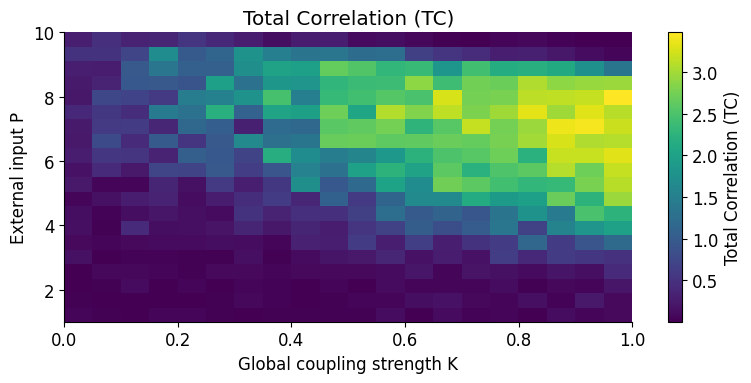

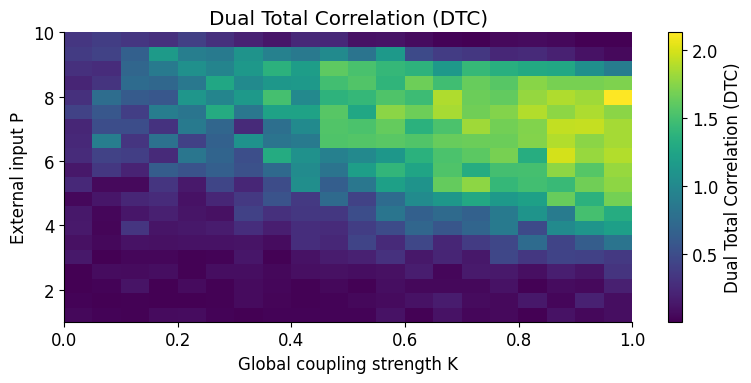

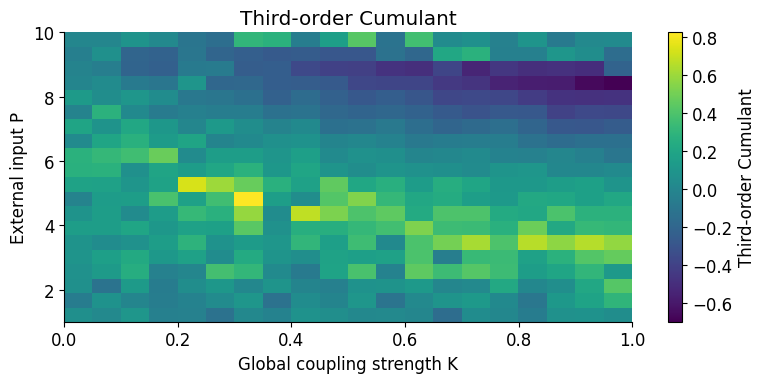

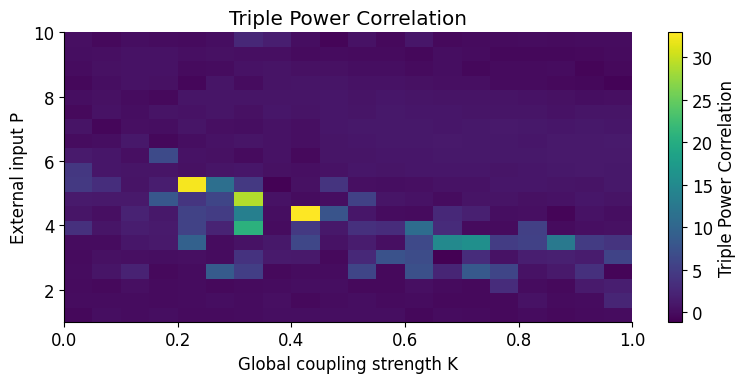

In [69]:
# -------------------------------------------------------------
# Higher-order metrics over the P–K sweep
# -------------------------------------------------------------

# Storage arrays
TC_map = np.zeros((len(P_values), len(K_values)))
DTC_map = np.zeros((len(P_values), len(K_values)))
Cumulant_map = np.zeros((len(P_values), len(K_values)))
PowerCorr_map = np.zeros((len(P_values), len(K_values)))

# Initial condition (fixed for all simulations)
state0 = 0.01 * np.random.randn(2 * N)

for i, P_val in enumerate(P_values):
    for j, K_val in enumerate(K_values):

        # Simulate dynamics
        t, states = simulate_wc_stochastic(
            state0=state0,
            P=P_val,
            K=K_val,
            M=M,
            T=T,
            dt=dt
        )

        # Extract excitatory activity
        E = states[:, :N]

        # Remove transient
        E_clean = E[start_idx:, :]

        # Data matrix for HO metrics
        X = E_clean.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics
        TC_map[i, j] = TC_gauss(Sigma)
        DTC_map[i, j] = DTC_gauss(Sigma)
        Cumulant_map[i, j] = cumulants(X)
        PowerCorr_map[i, j] = powercorr(X)




# -------------------------------------------------------------
# Visualization of higher-order metrics
# -------------------------------------------------------------

metrics = {
    "Total Correlation (TC)": TC_map,
    "Dual Total Correlation (DTC)": DTC_map,
    "Third-order Cumulant": Cumulant_map,
    "Triple Power Correlation": PowerCorr_map
}

for title, data in metrics.items():
    plt.figure()
    plt.imshow(
        data,
        origin="lower",
        aspect="auto",
        extent=[
            K_values.min(), K_values.max(),
            P_values.min(), P_values.max()
        ]
    )
    plt.colorbar(label=title)
    plt.xlabel("Global coupling strength K")
    plt.ylabel("External input P")
    plt.title(title)
    plt.tight_layout()
    plt.show()


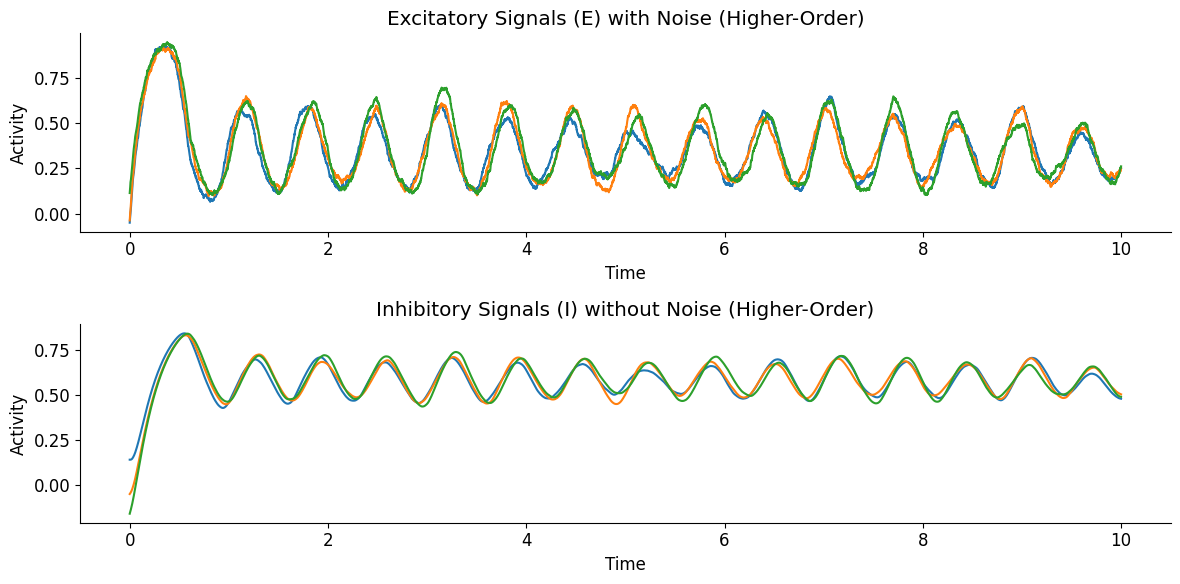

In [66]:
# Parámetros de simulación
P_sim = 5.0
K3_sim = 0.5
sigma_E = 0.01

# Estado inicial
state0 = 0.1 * np.random.randn(2 * N_nodes)

# Simulación con interacciones de alto orden y ruido en E
t, states = simulate_wc_higher_order_stochastic(
    state0=state0,
    P=P_sim,
    K3=K3_sim,
    T_ho=T_ho,
    T=T,
    dt=dt,
    sigma_E=sigma_E
)

# Extraer señales excitatorias e inhibitorias
E = states[:, :N_nodes]
I = states[:, N_nodes:]

# Visualización
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, E)
plt.title("Excitatory Signals (E) with Noise (Higher-Order)")
plt.xlabel("Time")
plt.ylabel("Activity")

plt.subplot(2, 1, 2)
plt.plot(t, I)
plt.title("Inhibitory Signals (I) without Noise (Higher-Order)")
plt.xlabel("Time")
plt.ylabel("Activity")

plt.tight_layout()
plt.show()


SIMULATION: P = 5, K3 = 0.5
Total timesteps: 10000
Analysis timesteps: 9000

Node 0:
  E: mean=0.3559, std=0.1765, range=[0.0869, 0.6837]
  I: mean=0.5859, std=0.0915, range=[0.4350, 0.7430]

Node 1:
  E: mean=0.3572, std=0.1661, range=[0.1080, 0.6658]
  I: mean=0.5901, std=0.0873, range=[0.4556, 0.7342]

Node 2:
  E: mean=0.3644, std=0.1864, range=[0.0729, 0.7131]
  I: mean=0.5916, std=0.0944, range=[0.4391, 0.7519]


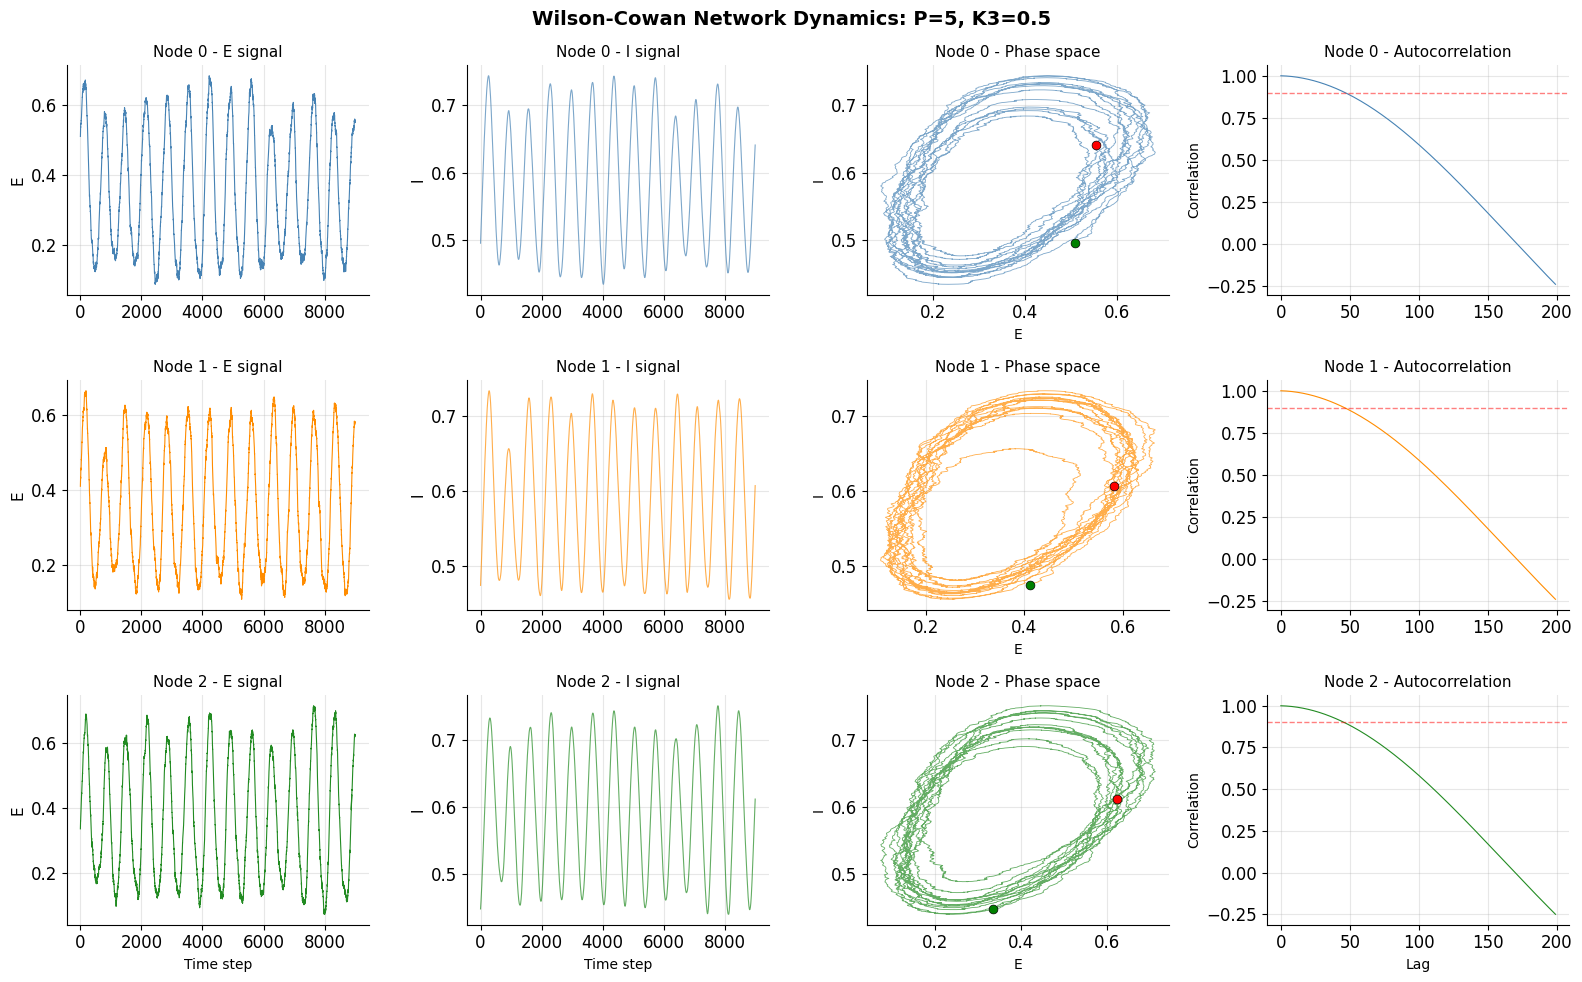

In [76]:
# -------------------------------------------------------------
# Simple single simulation with visualization for all 3 nodes
# -------------------------------------------------------------

# Set parameters
#P_sim = 1.32   # External input strength
#K3_sim = 0.7  # Higher-order coupling strength
P_sim = 5   # External input strength
K3_sim = 0.5  # Higher-order coupling strength



# Initial conditions
state0 = 0.1 * np.random.randn(2 * N_nodes)

print("=" * 60)
print(f"SIMULATION: P = {P_sim}, K3 = {K3_sim}")
print("=" * 60)

# Run simulation
t, states = simulate_wc_higher_order_stochastic(
                                                state0=state0,
                                                P=P_sim,
                                                K3=K3_sim,
                                                T_ho=T_ho,
                                                T=T,
                                                dt=dt,
                                                sigma_E=sigma_E
                                            )

# Remove transient (first half)
#start_idx = len(states) // 2

# Remove transient (first 1 second)
transient_time = 1.0          # seconds
transient_steps = int(transient_time / dt)

start_idx = transient_steps

# Extract excitatory and inhibitory signals
E = states[start_idx:, :N_nodes]
I = states[start_idx:, N_nodes:]

print(f"Total timesteps: {len(states)}")
print(f"Analysis timesteps: {len(E)}")

# Visualization for all 3 nodes
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

colors = ['steelblue', 'darkorange', 'forestgreen']
node_labels = ['Node 0', 'Node 1', 'Node 2']

for node in range(N_nodes):
    E_node = E[:, node]
    I_node = I[:, node]
    
    # Statistics
    print(f"\n{node_labels[node]}:")
    print(f"  E: mean={E_node.mean():.4f}, std={np.std(E_node):.4f}, range=[{E_node.min():.4f}, {E_node.max():.4f}]")
    print(f"  I: mean={I_node.mean():.4f}, std={np.std(I_node):.4f}, range=[{I_node.min():.4f}, {I_node.max():.4f}]")
    
    # Excitatory time series
    axes[node, 0].plot(E_node, linewidth=0.8, color=colors[node])
    axes[node, 0].set_ylabel("E", fontsize=11)
    axes[node, 0].set_title(f"{node_labels[node]} - E signal", fontsize=11)
    axes[node, 0].grid(True, alpha=0.3)
    if node == 2:
        axes[node, 0].set_xlabel("Time step", fontsize=10)
    
    # Inhibitory time series
    axes[node, 1].plot(I_node, linewidth=0.8, color=colors[node], alpha=0.7)
    axes[node, 1].set_ylabel("I", fontsize=11)
    axes[node, 1].set_title(f"{node_labels[node]} - I signal", fontsize=11)
    axes[node, 1].grid(True, alpha=0.3)
    if node == 2:
        axes[node, 1].set_xlabel("Time step", fontsize=10)
    
    # Phase space (E vs I)
    axes[node, 2].plot(E_node, I_node, alpha=0.7, linewidth=0.6, color=colors[node])
    axes[node, 2].scatter(E_node[0], I_node[0], c='green', s=40, zorder=5, edgecolors='black', linewidths=0.5)
    axes[node, 2].scatter(E_node[-1], I_node[-1], c='red', s=40, zorder=5, edgecolors='black', linewidths=0.5)
    axes[node, 2].set_xlabel("E", fontsize=10)
    axes[node, 2].set_ylabel("I", fontsize=10)
    axes[node, 2].set_title(f"{node_labels[node]} - Phase space", fontsize=11)
    axes[node, 2].grid(True, alpha=0.3)
    
    # Autocorrelation
    E_centered = E_node - np.mean(E_node)
    if np.std(E_centered) > 1e-6:
        autocorr = np.correlate(E_centered, E_centered, mode='full')
        autocorr = autocorr[len(autocorr)//2:]
        autocorr = autocorr / autocorr[0]
        
        axes[node, 3].plot(autocorr[:min(200, len(autocorr))], linewidth=0.8, color=colors[node])
        axes[node, 3].axhline(y=0.9, color='r', linestyle='--', alpha=0.5, linewidth=1)
        axes[node, 3].set_ylabel("Correlation", fontsize=10)
        axes[node, 3].set_title(f"{node_labels[node]} - Autocorrelation", fontsize=11)
        axes[node, 3].grid(True, alpha=0.3)
        if node == 2:
            axes[node, 3].set_xlabel("Lag", fontsize=10)

plt.suptitle(f"Wilson-Cowan Network Dynamics: P={P_sim}, K3={K3_sim}", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

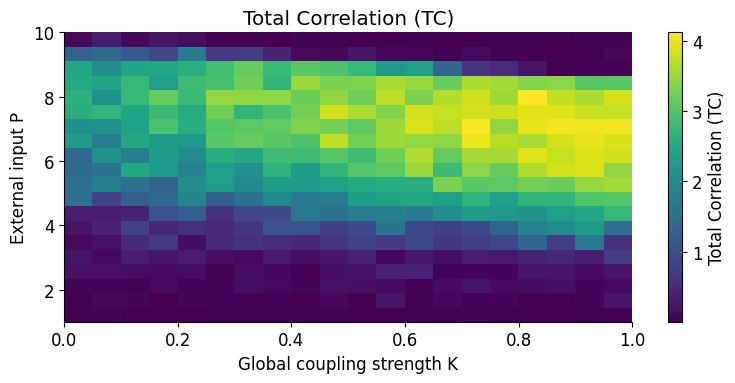

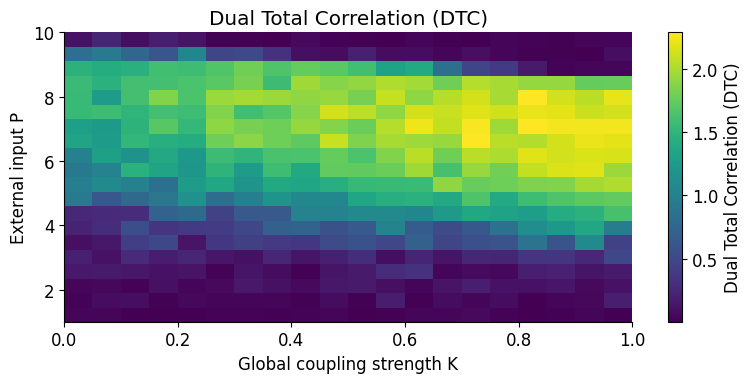

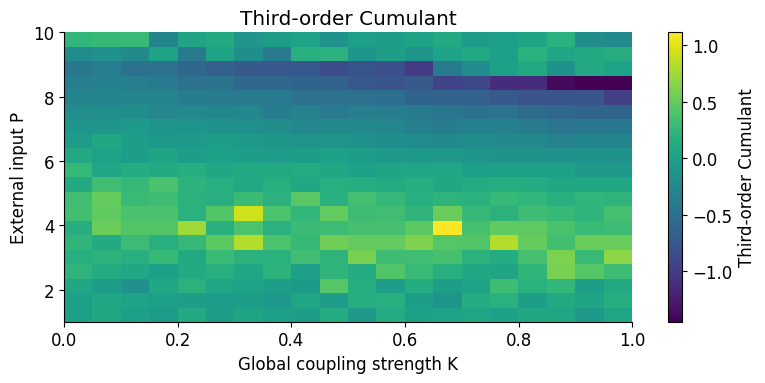

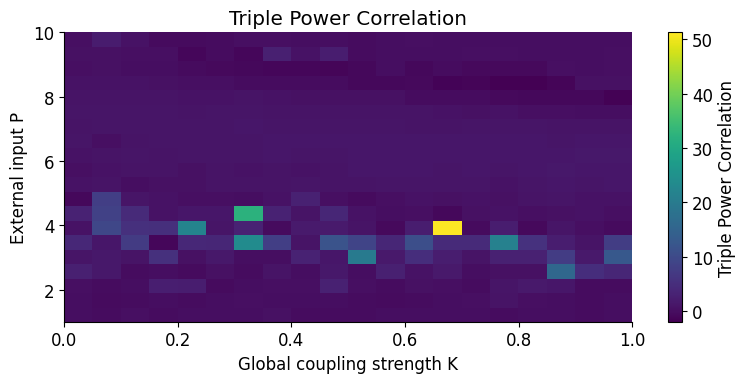

In [78]:
# -------------------------------------------------------------
# Higher-order metrics over the P–K sweep
# -------------------------------------------------------------

# Storage arrays
TC_map = np.zeros((len(P_values), len(K_values)))
DTC_map = np.zeros((len(P_values), len(K_values)))
Cumulant_map = np.zeros((len(P_values), len(K_values)))
PowerCorr_map = np.zeros((len(P_values), len(K_values)))

# Initial condition (fixed for all simulations)
state0 = 0.01 * np.random.randn(2 * N)

for i, P_val in enumerate(P_values):
    for j, K_val in enumerate(K_values):

        # Simulate dynamics
        t, states = simulate_wc_higher_order_stochastic(
                                                state0=state0,
                                                P=P_val,
                                                K3=K_val,
                                                T_ho=T_ho,
                                                T=T,
                                                dt=dt,
                                                sigma_E=sigma_E
                                            )

        # Extract excitatory activity
        E = states[:, :N]

        # Remove transient
        E_clean = E[start_idx:, :]

        # Data matrix for HO metrics
        X = E_clean.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics
        TC_map[i, j] = TC_gauss(Sigma)
        DTC_map[i, j] = DTC_gauss(Sigma)
        Cumulant_map[i, j] = cumulants(X)
        PowerCorr_map[i, j] = powercorr(X)




# -------------------------------------------------------------
# Visualization of higher-order metrics
# -------------------------------------------------------------

metrics = {
    "Total Correlation (TC)": TC_map,
    "Dual Total Correlation (DTC)": DTC_map,
    "Third-order Cumulant": Cumulant_map,
    "Triple Power Correlation": PowerCorr_map
}

for title, data in metrics.items():
    plt.figure()
    plt.imshow(
        data,
        origin="lower",
        aspect="auto",
        extent=[
            K_values.min(), K_values.max(),
            P_values.min(), P_values.max()
        ]
    )
    plt.colorbar(label=title)
    plt.xlabel("Global coupling strength K")
    plt.ylabel("External input P")
    plt.title(title)
    plt.tight_layout()
    plt.show()
